# DQN with CartPole-v2 Environment

This notebook loads [config.yaml](config.yaml) and trains the `QAgent` on `CartPole-v1` using the Gymnassium API for envrionment.

CartPole has a `Box(4,)` **observation space** and a `Discrete(2)` **action space**, so DQN uses the continuous state and the native discrete actions while training, during analysis we break it down based on our analysis discretisation config to look at the various statistics.

## Imports

In [1]:

import sys, pathlib, yaml
from functools import partial
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from environments.base_env import make_environment
from agents.q_agent import QAgent
from training import dqn_training_loop
from analysis.low_rank.hankel_policy import hankel_rollout
from analysis.low_rank.tabular_q_matrix import q_matrix_dqn
from analysis.low_rank.rank import plot_matrix_spectra, row_rank_property_check

## Reading the `config` file

In [2]:
# Reading the experiment config file
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

# Gathering torch backend and experiment seed
dev = cfg["experiment"]["device"]
device = dev if (dev != "mps" or torch.backends.mps.is_available()) else "cpu"
seed = cfg["experiment"]["seed"]
torch.manual_seed(seed)
np.random.seed(seed)

cfg

{'experiment': {'name': 'dqn_cartpole', 'seed': 52, 'device': 'mps'},
 'environment': {'name': 'CartPole-v1',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {},
   'state': {'min': [-4.8, -10, -0.41887903, -10],
    'max': [4.8, 10, 0.41887903, 10]}},
  'clip': {'action': False,
   'state': {'min': [None, -100, None, -100], 'max': [None, 100, None, 100]}}},
 'network': {'hidden_sizes': [128, 128]},
 'agent': {'replay_buffer_capacity': 100000,
  'batch_size': 128,
  'nn_learning_rate': 0.0005,
  'eps_start': 1.0,
  'eps_min': 0.01,
  'decay_rate': 0.99992,
  'discount_factor': 0.99,
  'TD_LR': 0.3,
  'buffer_util': 1,
  'gd_steps_ceil': 40,
  'double': True},
 'training': {'no_episodes': 1500,
  'target_network_update_steps': 50,
  'train_frequency_steps': 100},
 'analysis': {'ep_freq': 50,
  'methods': [{'name': 'hankel_rollout',
    'kwargs': {'seed': 52},
    'outputs': ['Hankel Q', 'Hankel V']},
   {'name': 'q_matrix_dqn',
    'kwargs': {'state_discretis

## Creating the Envrionment

In [3]:
env_cfg = cfg["environment"]
env = make_environment(
    env_cfg["name"],
    render_mode=env_cfg["render_mode"],
    discrete_config=env_cfg["discrete_config"],   # None -> no discretisation
    normalise=env_cfg["normalise"],               # {action:{}, state:{}} -> no rescaling
    clip=env_cfg["clip"],
)
obs_dim = env.observation_space.shape[0]         
n_actions = env.action_space.n                    
print("obs_dim:", obs_dim, "n_actions:", n_actions)

obs_dim: 4 n_actions: 2


## Creating the Agent

In [4]:
class QNetwork(nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by QAgent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [5]:

a = cfg["agent"]
nn_extra_kwargs = {
    "in_dim": obs_dim,
    "out_dim": n_actions,
    "hidden_sizes": cfg["network"]["hidden_sizes"],
}
agent = QAgent(
    replay_buffer_capacity=a["replay_buffer_capacity"],
    q_network=QNetwork,
    batch_size=a["batch_size"],
    nn_learning_rate=a["nn_learning_rate"],
    nn_extra_kwargs=nn_extra_kwargs,
    env=env,
    eps_start=a["eps_start"],
    eps_min=a["eps_min"],
    decay_rate=a["decay_rate"],
    discount_factor=a["discount_factor"],
    device=device,
    TD_LR=a["TD_LR"],
    buffer_util=a["buffer_util"],
    gd_steps_ceil=a["gd_steps_ceil"],
    double=a["double"]
)

## Analysis (Low Rank)

In [6]:
analysis = cfg["analysis"]

# registry mapping config.yaml strings for methods to callable function objects
analysis_methods = {
    "hankel_rollout": hankel_rollout,
    "q_matrix_dqn": q_matrix_dqn,
}

# Each config entry is {name, kwargs, outputs}. Resolve `name` to its callable,
# pre-bind config-supplied `kwargs` with functools.partial, and pair it with the
# list of output names so the training loop knows how many matrices to expect.
analysis["methods"] = [
    (partial(analysis_methods[m["name"]], **m.get("kwargs", {})), m["outputs"])
    for m in analysis["methods"]
]
analysis

{'ep_freq': 50,
 'methods': [(functools.partial(<function hankel_rollout at 0x137c83ba0>, seed=52),
   ['Hankel Q', 'Hankel V']),
  (functools.partial(<function q_matrix_dqn at 0x137c83a60>, state_discretisation=[8, 8, 8, 8], batch_size=64),
   ['Q-function'])]}

## Agent Training 

  0%|          | 0/1500 [00:00<?, ?it/s]

episode 0 avg_rewarg: 1.3
****************************Hankel Q****************************


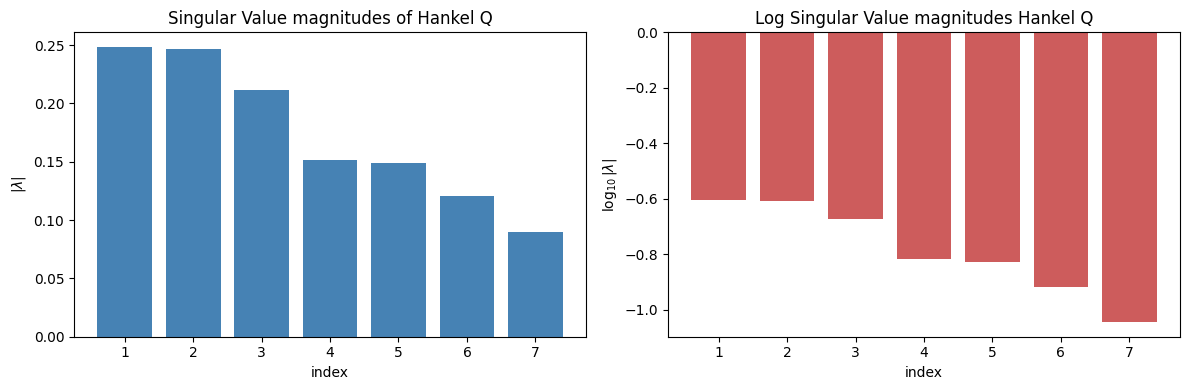

eff_rank: 5, stable_rank: 3.81, shape: (7, 7), non-zero rows :7, non-zero cols:7
top-r leverage spread: min=0.1213 max=0.1751 (uniform would be 0.1429)
row-space coherence score: 1.226
****************************Hankel V****************************


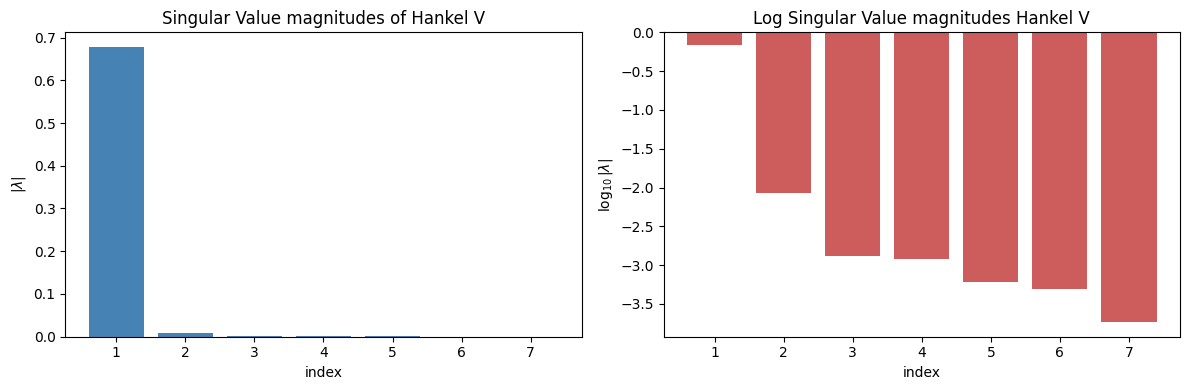

eff_rank: 1, stable_rank: 1.00, shape: (7, 7), non-zero rows :7, non-zero cols:7
top-r leverage spread: min=0.1342 max=0.1566 (uniform would be 0.1429)
row-space coherence score: 1.096
****************************Q-function****************************


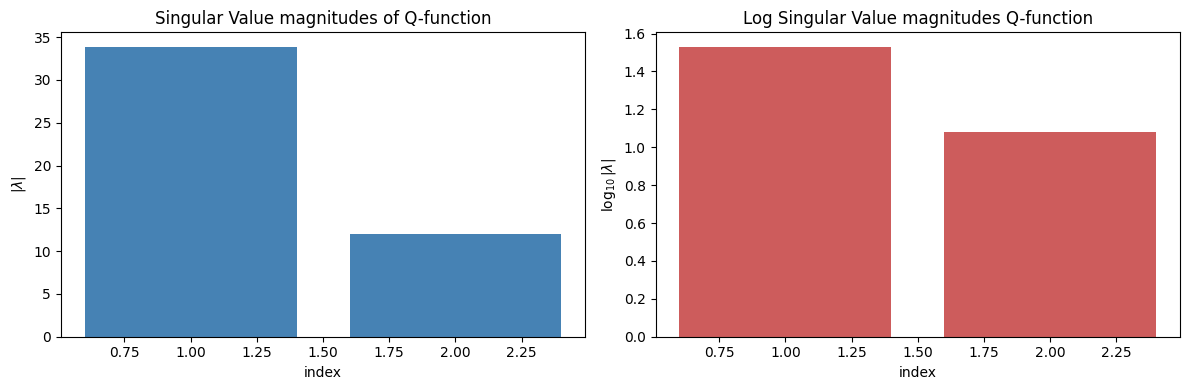

  0%|          | 1/1500 [00:00<17:31,  1.43it/s]

eff_rank: 2, stable_rank: 1.13, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=4.366e-06 max=0.001463 (uniform would be 0.0002441)
row-space coherence score: 5.992


  1%|          | 13/1500 [00:01<01:33, 15.93it/s]

episode 10 avg_rewarg: 16.2


  2%|▏         | 27/1500 [00:01<00:51, 28.67it/s]

episode 20 avg_rewarg: 21.6


  2%|▏         | 32/1500 [00:01<00:45, 32.61it/s]

episode 30 avg_rewarg: 22.0


  3%|▎         | 48/1500 [00:02<00:40, 35.67it/s]

episode 40 avg_rewarg: 28.4
episode 50 avg_rewarg: 18.4
****************************Hankel Q****************************


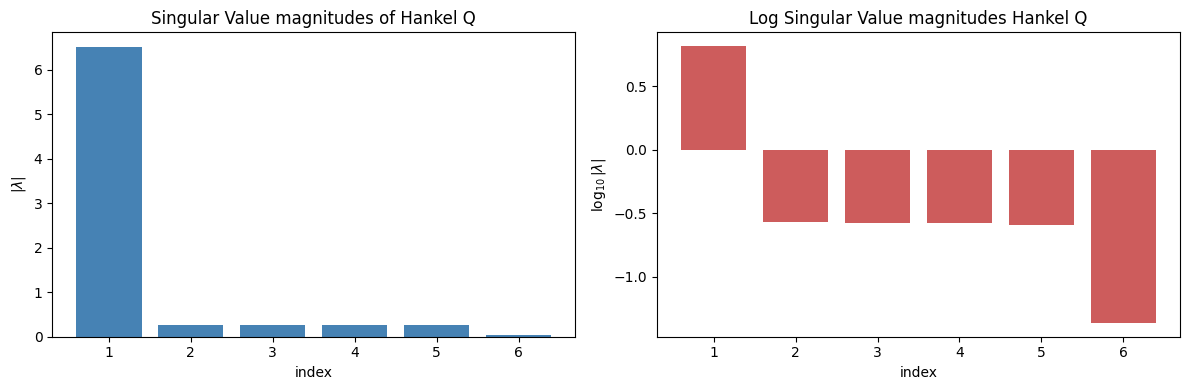

eff_rank: 1, stable_rank: 1.01, shape: (6, 6), non-zero rows :6, non-zero cols:6
top-r leverage spread: min=0.1622 max=0.1795 (uniform would be 0.1667)
row-space coherence score: 1.077
****************************Hankel V****************************


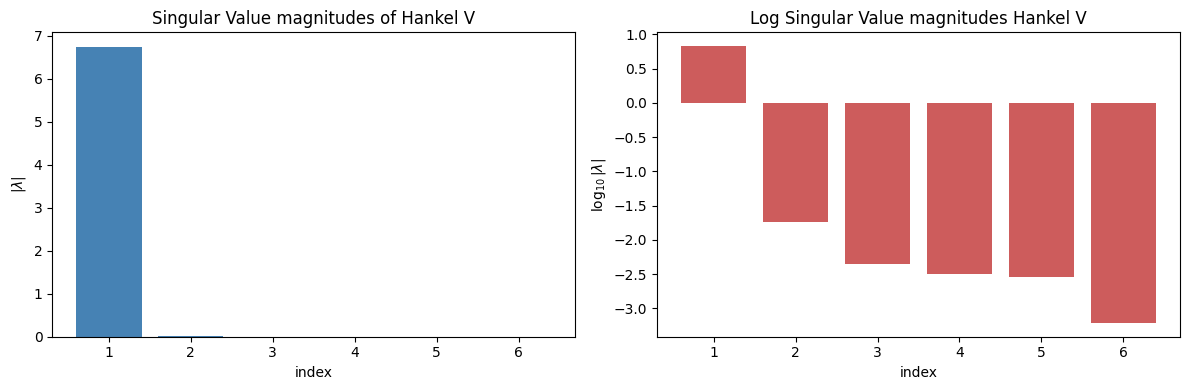

eff_rank: 1, stable_rank: 1.00, shape: (6, 6), non-zero rows :6, non-zero cols:6
top-r leverage spread: min=0.1647 max=0.1696 (uniform would be 0.1667)
row-space coherence score: 1.017
****************************Q-function****************************


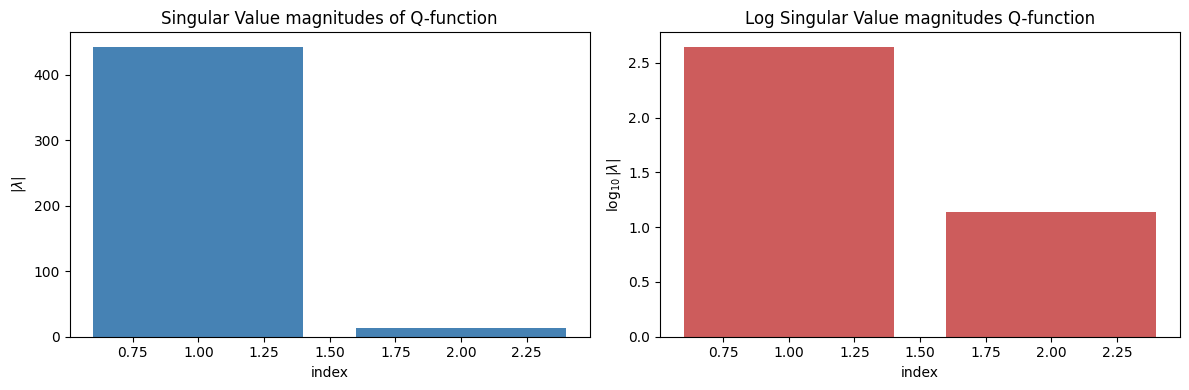

  3%|▎         | 52/1500 [00:02<01:09, 20.92it/s]

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=2.214e-05 max=0.000637 (uniform would be 0.0002441)
row-space coherence score: 2.609


  4%|▍         | 64/1500 [00:02<00:53, 26.67it/s]

episode 60 avg_rewarg: 17.2


  5%|▍         | 72/1500 [00:03<00:53, 26.70it/s]

...

episode 80 avg_rewarg: 22.3


  6%|▋         | 96/1500 [00:03<00:46, 30.35it/s]

episode 90 avg_rewarg: 22.4


  7%|▋         | 100/1500 [00:04<00:48, 28.73it/s]

episode 100 avg_rewarg: 19.2
****************************Hankel Q****************************


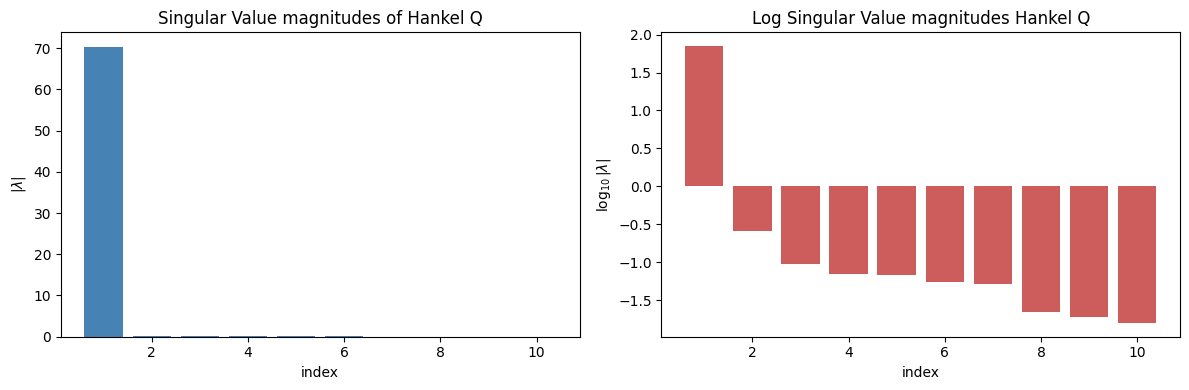

eff_rank: 1, stable_rank: 1.00, shape: (11, 10), non-zero rows :11, non-zero cols:10
top-r leverage spread: min=0.08937 max=0.09332 (uniform would be 0.09091)
row-space coherence score: 1.027
****************************Hankel V****************************


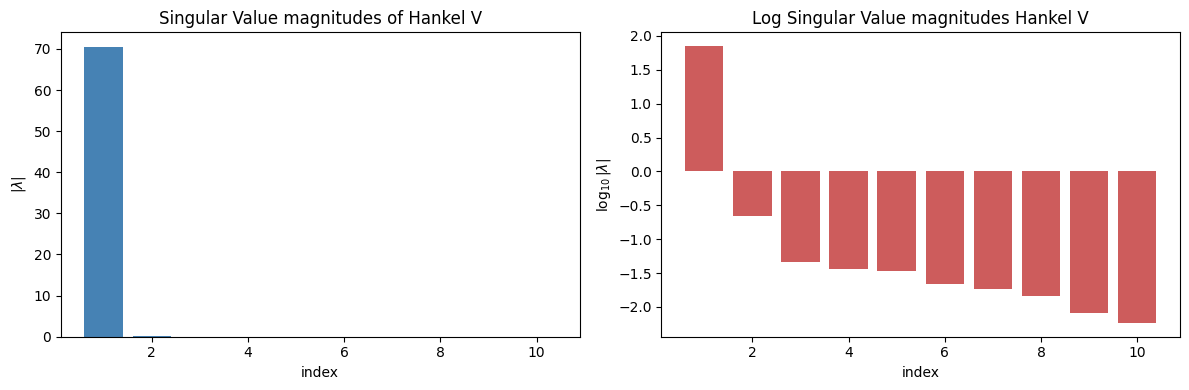

eff_rank: 1, stable_rank: 1.00, shape: (11, 10), non-zero rows :11, non-zero cols:10
top-r leverage spread: min=0.08943 max=0.09326 (uniform would be 0.09091)
row-space coherence score: 1.026
****************************Q-function****************************


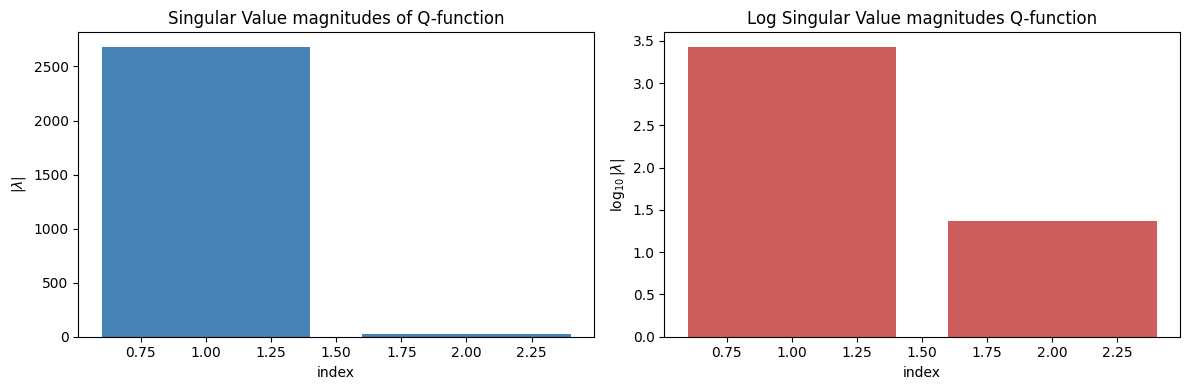

  7%|▋         | 103/1500 [00:04<01:20, 17.44it/s]

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=2.138e-05 max=0.0006176 (uniform would be 0.0002441)
row-space coherence score: 2.53


  8%|▊         | 113/1500 [00:05<01:11, 19.42it/s]

episode 110 avg_rewarg: 25.0


  8%|▊         | 123/1500 [00:05<01:03, 21.56it/s]

...

episode 130 avg_rewarg: 14.2


 10%|▉         | 143/1500 [00:06<00:57, 23.67it/s]

episode 140 avg_rewarg: 15.9


 10%|▉         | 148/1500 [00:06<00:56, 23.89it/s]

episode 150 avg_rewarg: 20.3
****************************Hankel Q****************************


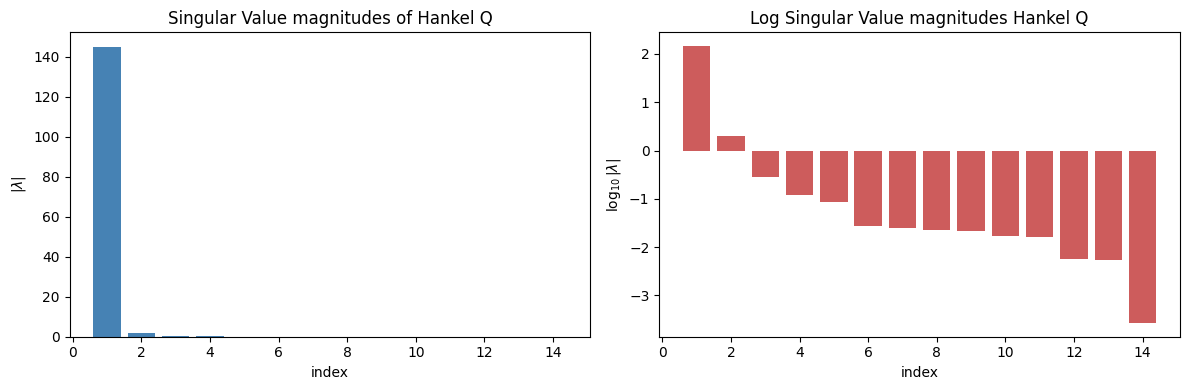

eff_rank: 1, stable_rank: 1.00, shape: (14, 14), non-zero rows :14, non-zero cols:14
top-r leverage spread: min=0.07044 max=0.07402 (uniform would be 0.07143)
row-space coherence score: 1.036
****************************Hankel V****************************


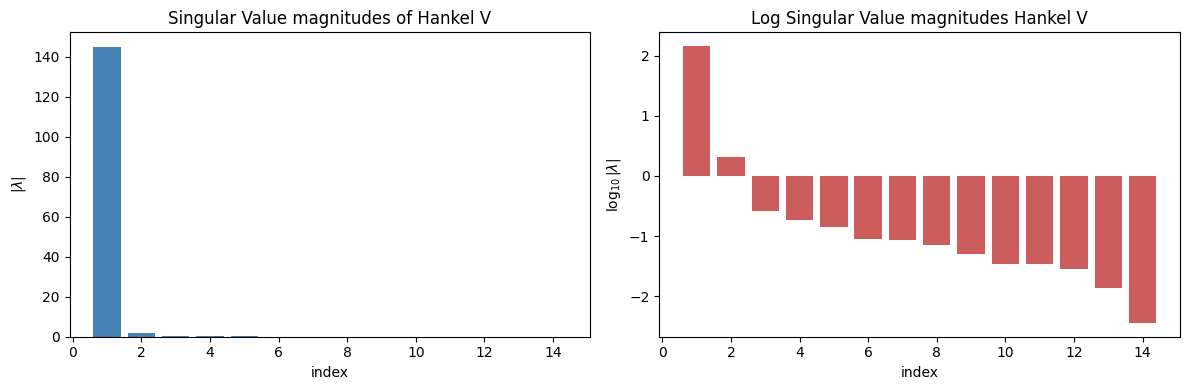

eff_rank: 1, stable_rank: 1.00, shape: (14, 14), non-zero rows :14, non-zero cols:14
top-r leverage spread: min=0.07043 max=0.07395 (uniform would be 0.07143)
row-space coherence score: 1.035
****************************Q-function****************************


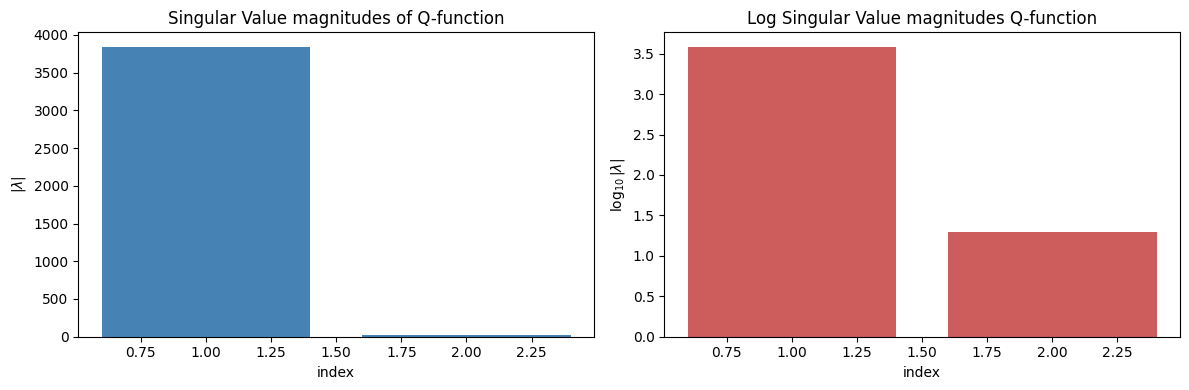

 10%|█         | 151/1500 [00:06<01:25, 15.77it/s]

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=2.229e-05 max=0.0007413 (uniform would be 0.0002441)
row-space coherence score: 3.036


 11%|█         | 161/1500 [00:07<01:09, 19.37it/s]

episode 160 avg_rewarg: 17.3


 11%|█▏        | 170/1500 [00:07<00:55, 23.78it/s]

...

episode 180 avg_rewarg: 28.1


 13%|█▎        | 193/1500 [00:09<01:06, 19.56it/s]

episode 190 avg_rewarg: 18.3


 13%|█▎        | 199/1500 [00:09<01:07, 19.36it/s]

episode 200 avg_rewarg: 16.4
****************************Hankel Q****************************


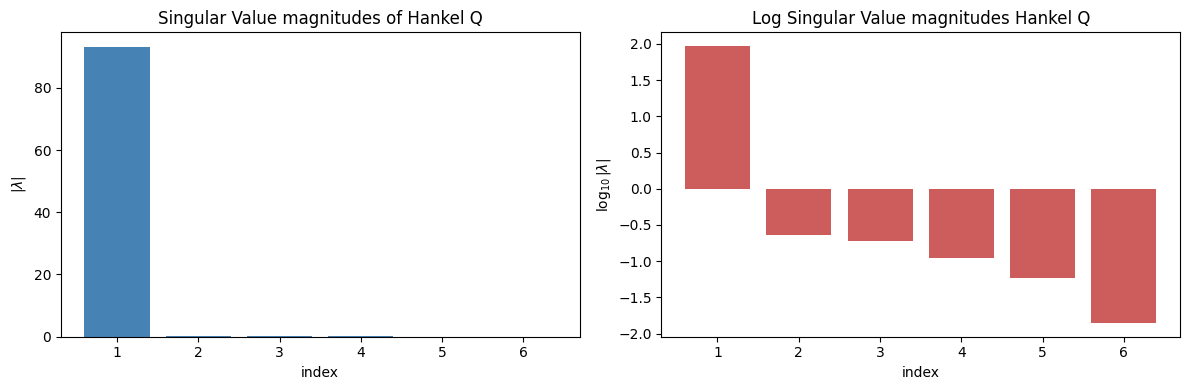

eff_rank: 1, stable_rank: 1.00, shape: (6, 6), non-zero rows :6, non-zero cols:6
top-r leverage spread: min=0.1613 max=0.1718 (uniform would be 0.1667)
row-space coherence score: 1.031
****************************Hankel V****************************


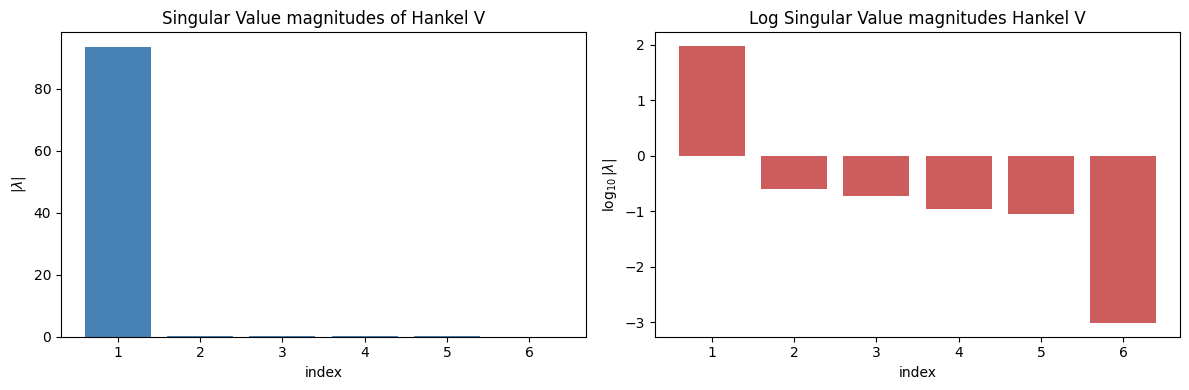

eff_rank: 1, stable_rank: 1.00, shape: (6, 6), non-zero rows :6, non-zero cols:6
top-r leverage spread: min=0.1609 max=0.1719 (uniform would be 0.1667)
row-space coherence score: 1.031
****************************Q-function****************************


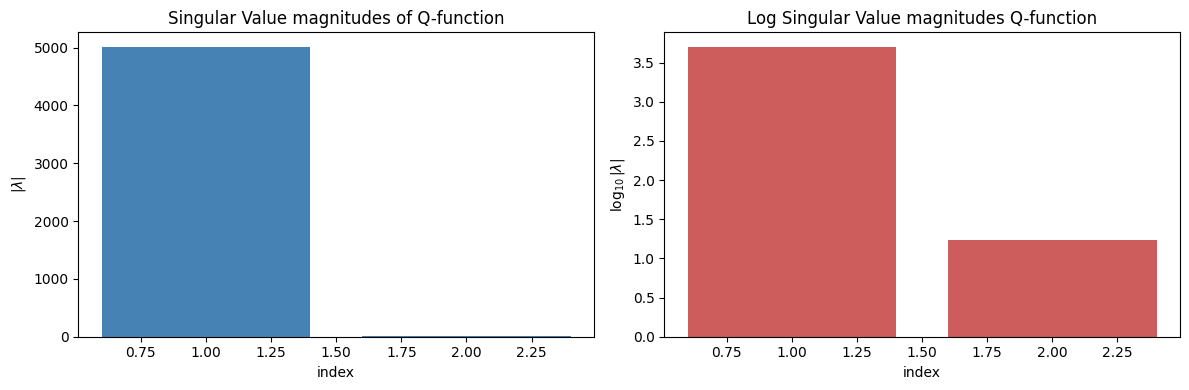

 13%|█▎        | 202/1500 [00:09<01:33, 13.89it/s]

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=1.511e-05 max=0.001065 (uniform would be 0.0002441)
row-space coherence score: 4.362


 14%|█▍        | 211/1500 [00:10<01:05, 19.69it/s]

episode 210 avg_rewarg: 15.5


 15%|█▍        | 222/1500 [00:10<01:14, 17.23it/s]

...

episode 230 avg_rewarg: 18.1


 16%|█▌        | 238/1500 [00:11<01:19, 15.79it/s]

episode 240 avg_rewarg: 21.3


 17%|█▋        | 248/1500 [00:12<00:59, 21.22it/s]

episode 250 avg_rewarg: 14.6
****************************Hankel Q****************************


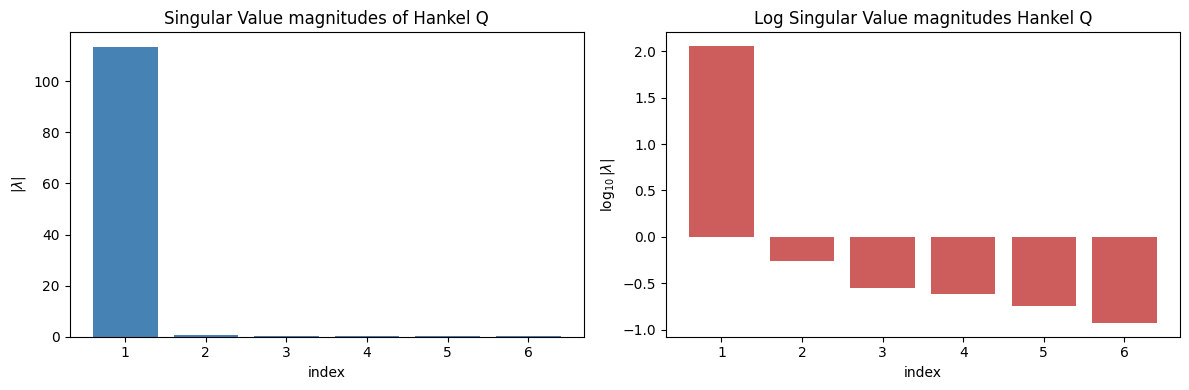

eff_rank: 1, stable_rank: 1.00, shape: (7, 6), non-zero rows :7, non-zero cols:6
top-r leverage spread: min=0.1323 max=0.155 (uniform would be 0.1429)
row-space coherence score: 1.085
****************************Hankel V****************************


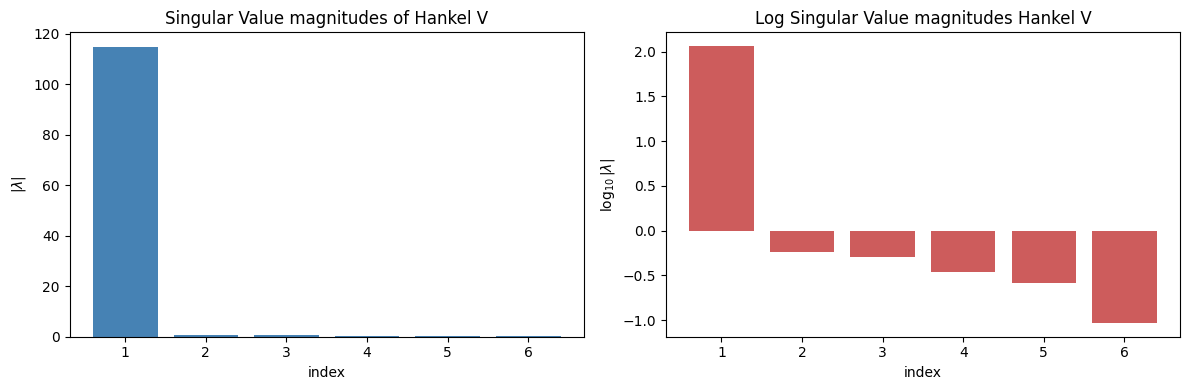

eff_rank: 1, stable_rank: 1.00, shape: (7, 6), non-zero rows :7, non-zero cols:6
top-r leverage spread: min=0.131 max=0.156 (uniform would be 0.1429)
row-space coherence score: 1.092
****************************Q-function****************************


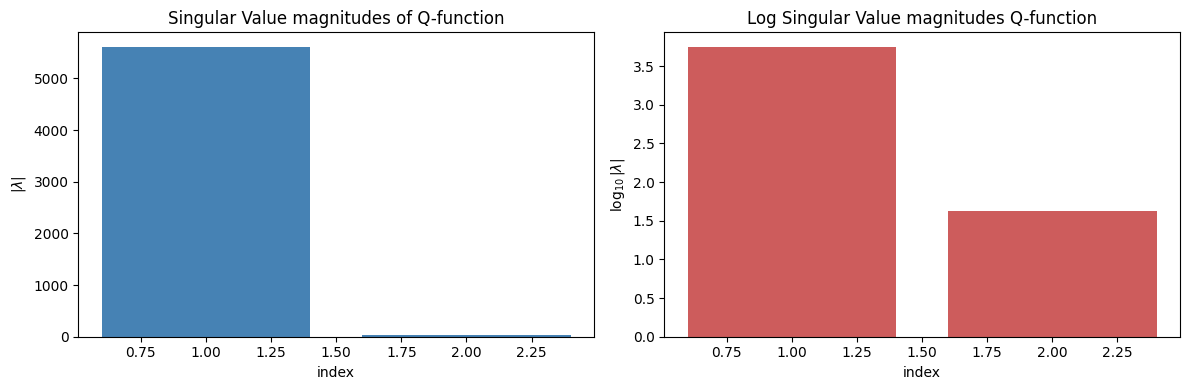

 17%|█▋        | 251/1500 [00:12<01:40, 12.43it/s]

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=8.218e-06 max=0.001336 (uniform would be 0.0002441)
row-space coherence score: 5.473


 17%|█▋        | 257/1500 [00:12<01:28, 14.06it/s]

episode 260 avg_rewarg: 15.4


 18%|█▊        | 270/1500 [00:13<01:13, 16.85it/s]

...

episode 280 avg_rewarg: 19.5


 20%|█▉        | 293/1500 [00:14<01:08, 17.56it/s]

episode 290 avg_rewarg: 16.5


 20%|█▉        | 296/1500 [00:15<01:14, 16.11it/s]

episode 300 avg_rewarg: 15.9
****************************Hankel Q****************************


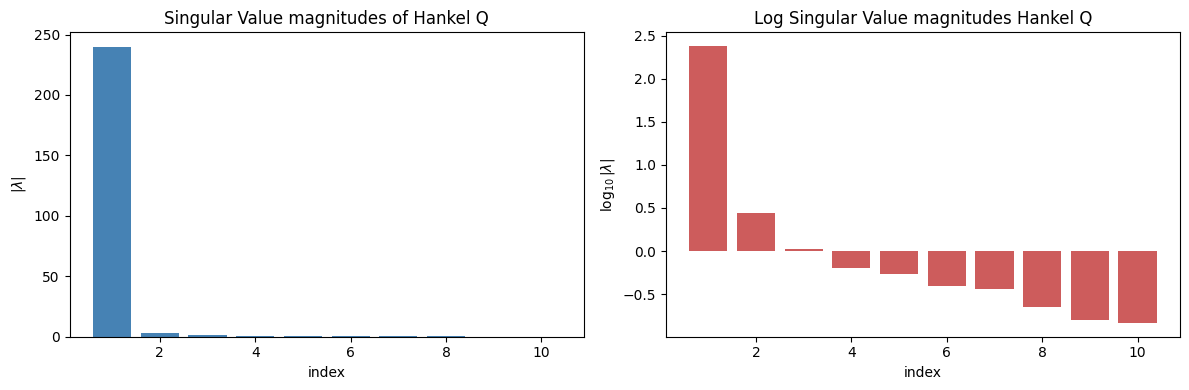

eff_rank: 1, stable_rank: 1.00, shape: (11, 10), non-zero rows :11, non-zero cols:10
top-r leverage spread: min=0.08717 max=0.0926 (uniform would be 0.09091)
row-space coherence score: 1.019
****************************Hankel V****************************


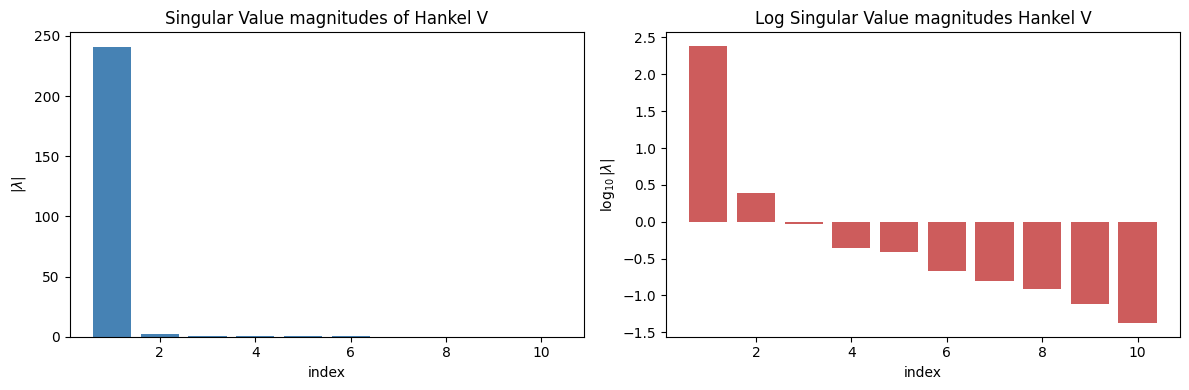

eff_rank: 1, stable_rank: 1.00, shape: (11, 10), non-zero rows :11, non-zero cols:10
top-r leverage spread: min=0.08751 max=0.09247 (uniform would be 0.09091)
row-space coherence score: 1.017
****************************Q-function****************************


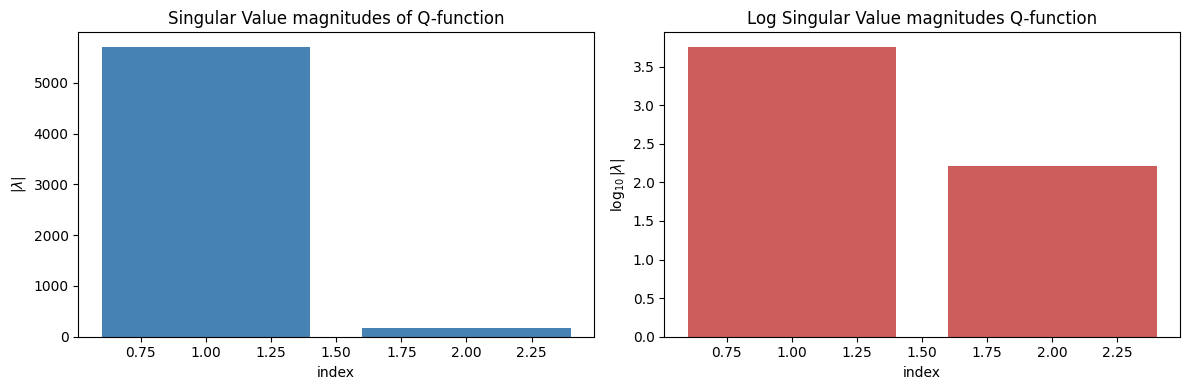

 20%|██        | 301/1500 [00:15<01:37, 12.24it/s]

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=1.509e-11 max=0.001478 (uniform would be 0.0002441)
row-space coherence score: 6.053


 21%|██        | 316/1500 [00:16<01:03, 18.76it/s]

episode 310 avg_rewarg: 15.5


 21%|██▏       | 319/1500 [00:16<01:10, 16.86it/s]

...

episode 330 avg_rewarg: 18.2


 23%|██▎       | 344/1500 [00:18<01:15, 15.41it/s]

episode 340 avg_rewarg: 23.5


 23%|██▎       | 350/1500 [00:19<02:48,  6.83it/s]

episode 350 avg_rewarg: 48.6
****************************Hankel Q****************************


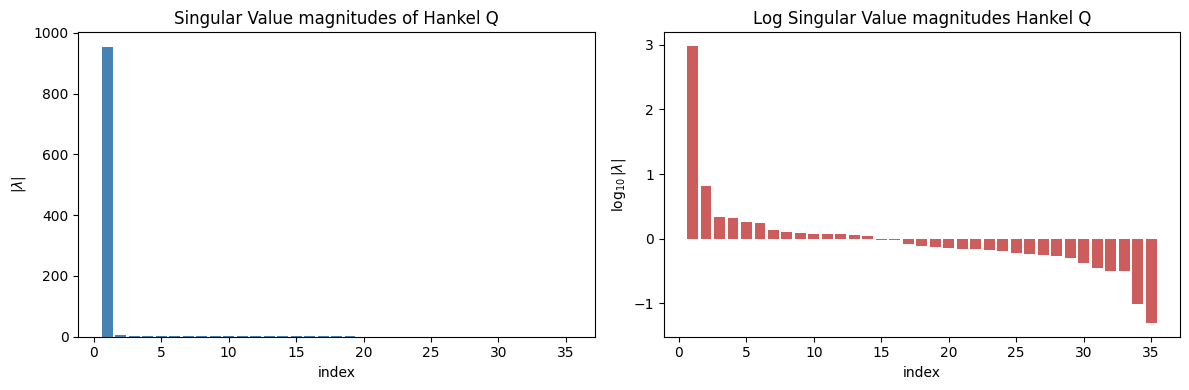

eff_rank: 1, stable_rank: 1.00, shape: (35, 35), non-zero rows :35, non-zero cols:35
top-r leverage spread: min=0.02716 max=0.02929 (uniform would be 0.02857)
row-space coherence score: 1.025
****************************Hankel V****************************


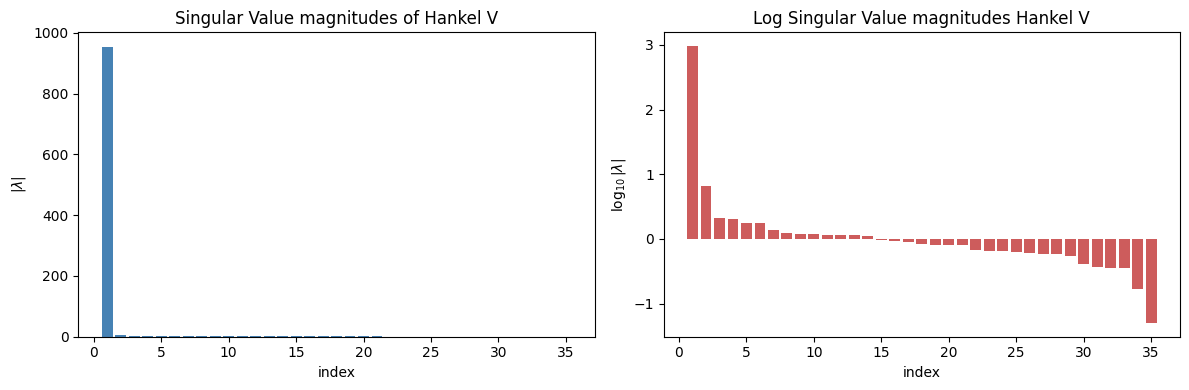

eff_rank: 1, stable_rank: 1.00, shape: (35, 35), non-zero rows :35, non-zero cols:35
top-r leverage spread: min=0.02716 max=0.0293 (uniform would be 0.02857)
row-space coherence score: 1.025
****************************Q-function****************************


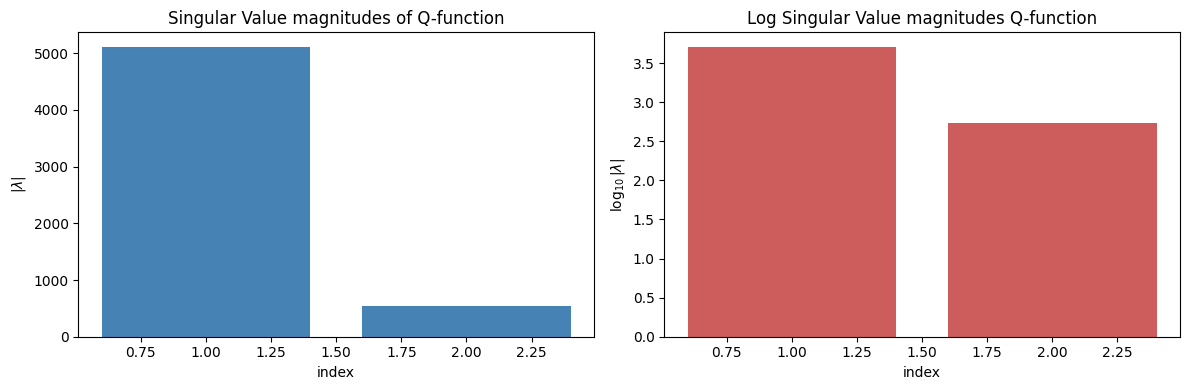

 23%|██▎       | 351/1500 [00:20<03:58,  4.81it/s]

eff_rank: 1, stable_rank: 1.01, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=1.092e-11 max=0.00105 (uniform would be 0.0002441)
row-space coherence score: 4.302


 24%|██▍       | 361/1500 [00:22<03:20,  5.68it/s]

episode 360 avg_rewarg: 54.3


 25%|██▍       | 371/1500 [00:23<02:54,  6.49it/s]

...

episode 380 avg_rewarg: 50.3


 26%|██▌       | 390/1500 [00:26<03:37,  5.10it/s]

episode 390 avg_rewarg: 49.2


 27%|██▋       | 400/1500 [00:28<03:14,  5.66it/s]

episode 400 avg_rewarg: 56.6
****************************Hankel Q****************************


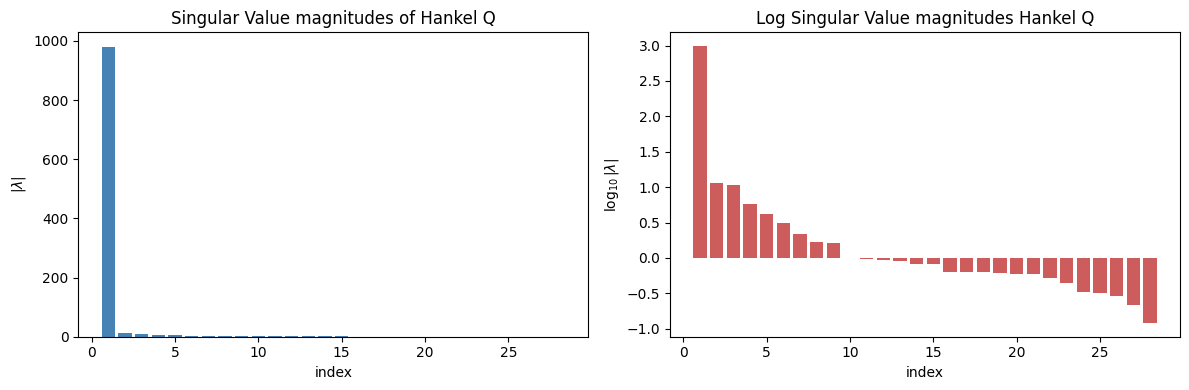

eff_rank: 1, stable_rank: 1.00, shape: (28, 28), non-zero rows :28, non-zero cols:28
top-r leverage spread: min=0.03303 max=0.03827 (uniform would be 0.03571)
row-space coherence score: 1.072
****************************Hankel V****************************


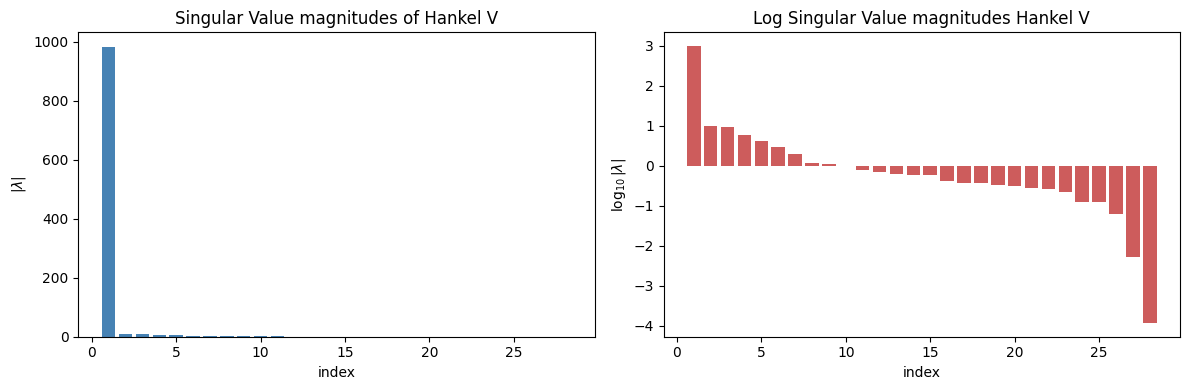

eff_rank: 1, stable_rank: 1.00, shape: (28, 28), non-zero rows :28, non-zero cols:28
top-r leverage spread: min=0.03309 max=0.03819 (uniform would be 0.03571)
row-space coherence score: 1.069
****************************Q-function****************************


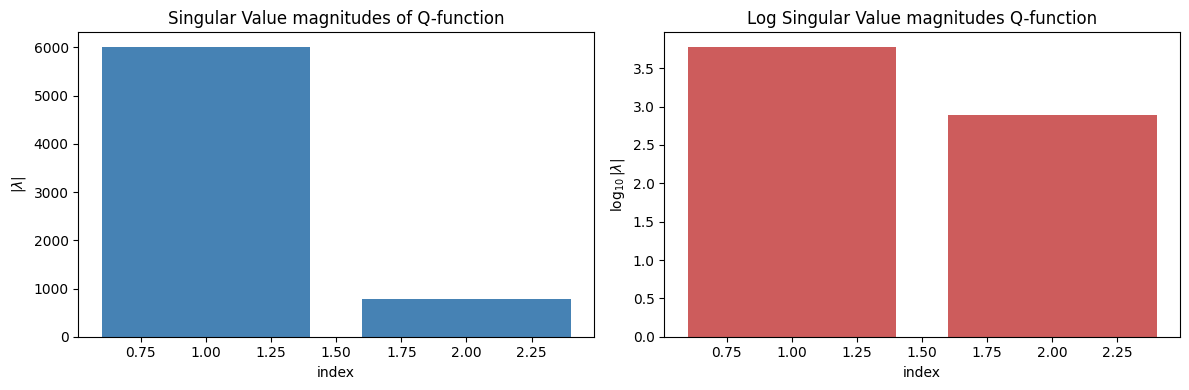

 27%|██▋       | 401/1500 [00:29<04:27,  4.10it/s]

eff_rank: 1, stable_rank: 1.02, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=2.722e-13 max=0.002073 (uniform would be 0.0002441)
row-space coherence score: 8.49


 27%|██▋       | 411/1500 [00:31<05:43,  3.17it/s]

episode 410 avg_rewarg: 74.3


 28%|██▊       | 421/1500 [00:34<05:00,  3.59it/s]

...

episode 430 avg_rewarg: 72.2


 29%|██▉       | 441/1500 [00:39<04:22,  4.03it/s]

episode 440 avg_rewarg: 74.2


 30%|██▉       | 449/1500 [00:42<06:44,  2.60it/s]

episode 450 avg_rewarg: 84.3
****************************Hankel Q****************************


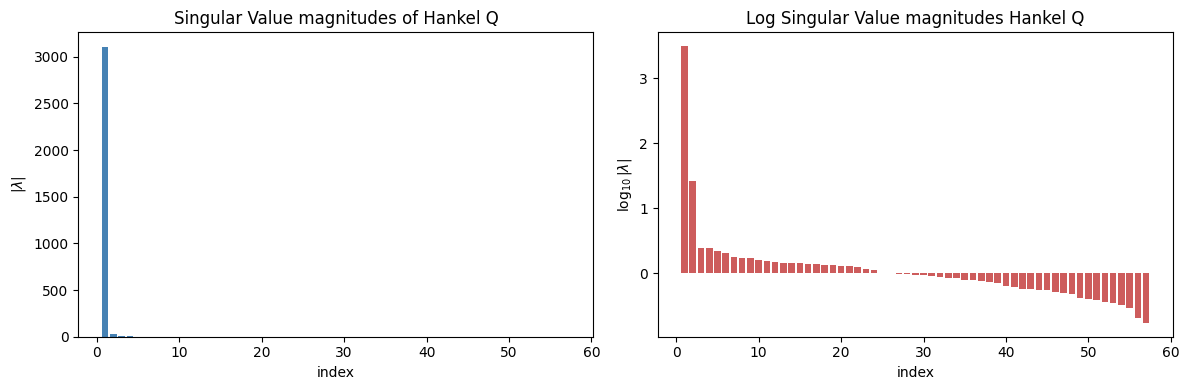

eff_rank: 1, stable_rank: 1.00, shape: (58, 57), non-zero rows :58, non-zero cols:57
top-r leverage spread: min=0.01616 max=0.01896 (uniform would be 0.01724)
row-space coherence score: 1.1
****************************Hankel V****************************


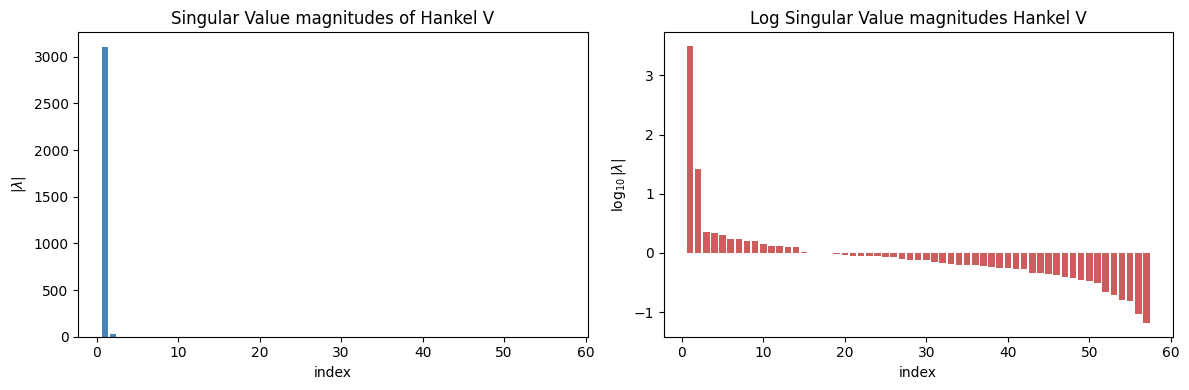

eff_rank: 1, stable_rank: 1.00, shape: (58, 57), non-zero rows :58, non-zero cols:57
top-r leverage spread: min=0.01616 max=0.01896 (uniform would be 0.01724)
row-space coherence score: 1.1
****************************Q-function****************************


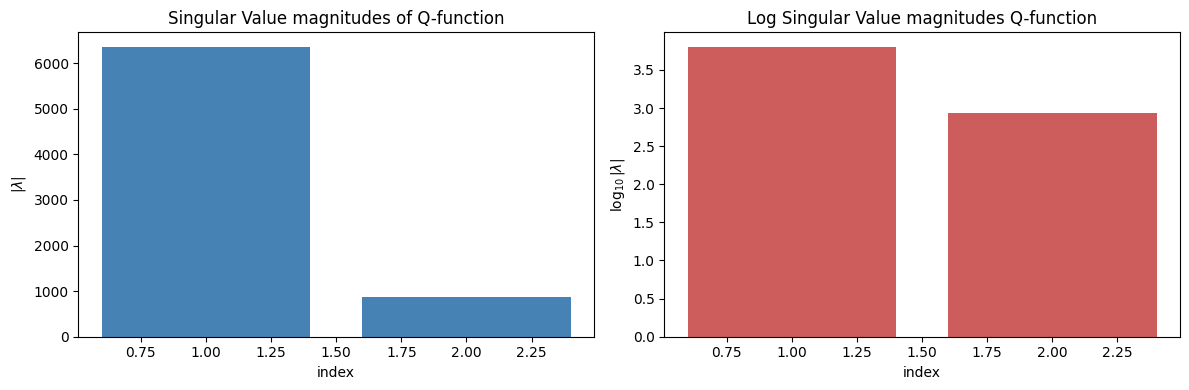

 30%|███       | 451/1500 [00:43<07:33,  2.31it/s]

eff_rank: 1, stable_rank: 1.02, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=2.079e-12 max=0.002724 (uniform would be 0.0002441)
row-space coherence score: 11.16


 31%|███       | 461/1500 [00:48<08:34,  2.02it/s]

episode 460 avg_rewarg: 156.4


 31%|███▏      | 471/1500 [00:54<09:18,  1.84it/s]

...

episode 480 avg_rewarg: 147.4


 33%|███▎      | 491/1500 [01:04<07:59,  2.10it/s]

episode 490 avg_rewarg: 140.4


 33%|███▎      | 500/1500 [01:08<06:59,  2.39it/s]

episode 500 avg_rewarg: 124.2
****************************Hankel Q****************************


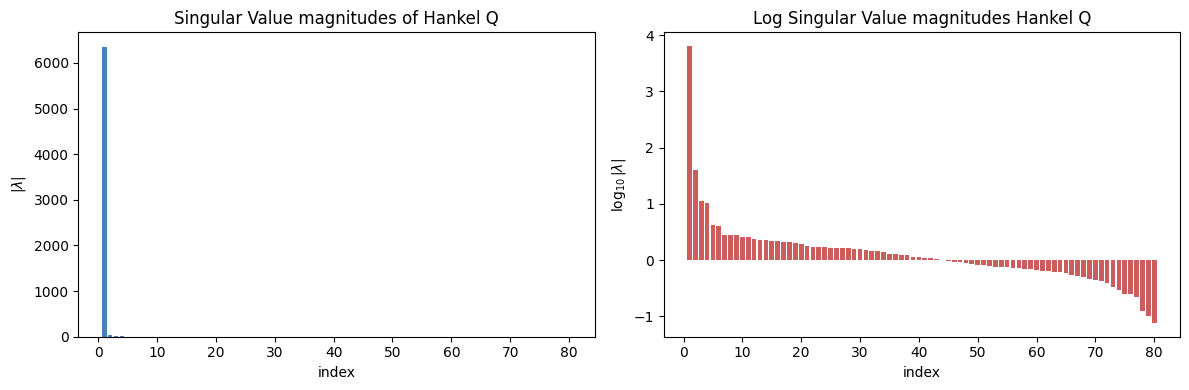

eff_rank: 1, stable_rank: 1.00, shape: (80, 80), non-zero rows :80, non-zero cols:80
top-r leverage spread: min=0.01119 max=0.01423 (uniform would be 0.0125)
row-space coherence score: 1.139
****************************Hankel V****************************


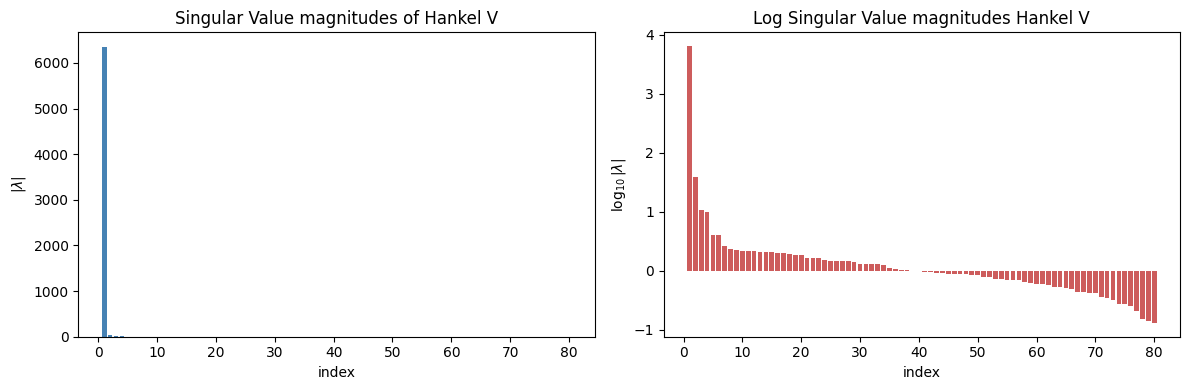

eff_rank: 1, stable_rank: 1.00, shape: (80, 80), non-zero rows :80, non-zero cols:80
top-r leverage spread: min=0.01119 max=0.01423 (uniform would be 0.0125)
row-space coherence score: 1.139
****************************Q-function****************************


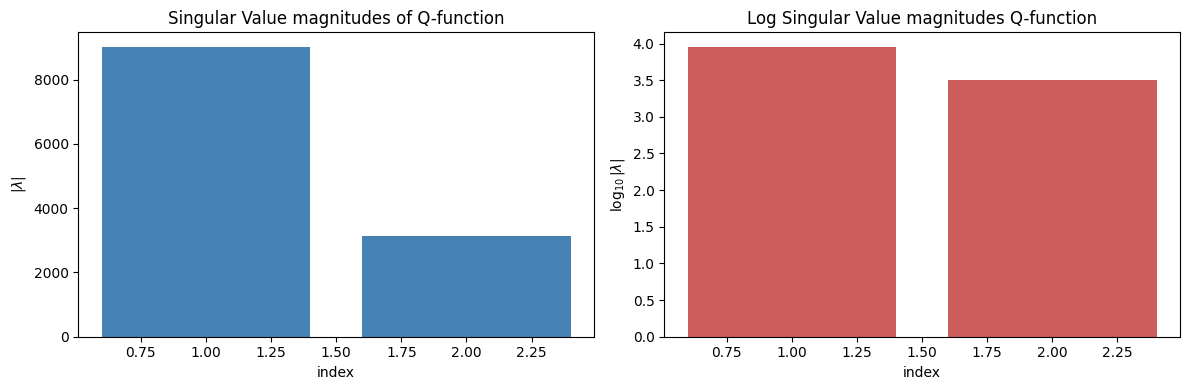

 33%|███▎      | 501/1500 [01:10<12:03,  1.38it/s]

eff_rank: 2, stable_rank: 1.12, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=1.388e-06 max=0.001614 (uniform would be 0.0002441)
row-space coherence score: 6.611


 34%|███▍      | 511/1500 [01:15<08:06,  2.03it/s]

episode 510 avg_rewarg: 132.9


 35%|███▍      | 521/1500 [01:20<08:24,  1.94it/s]

...

episode 530 avg_rewarg: 147.2


 36%|███▌      | 541/1500 [01:32<11:02,  1.45it/s]

episode 540 avg_rewarg: 181.1


 37%|███▋      | 550/1500 [01:40<15:28,  1.02it/s]

episode 550 avg_rewarg: 229.5
****************************Hankel Q****************************


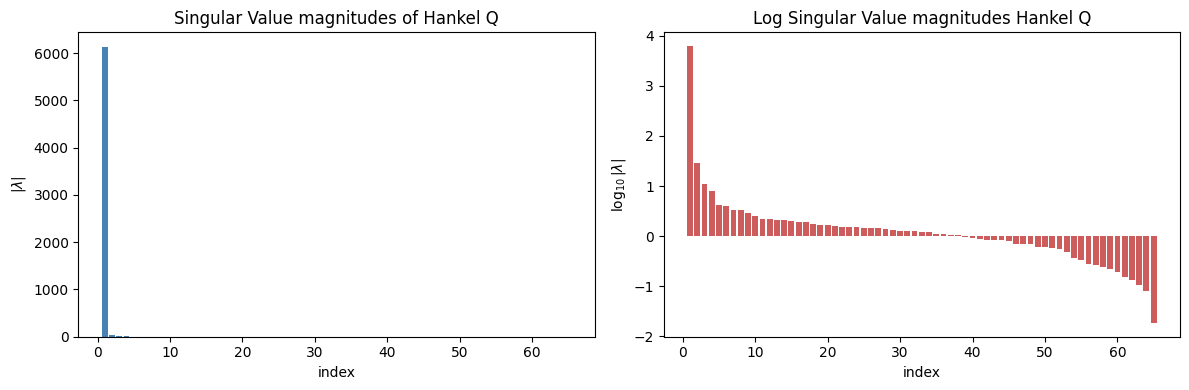

eff_rank: 1, stable_rank: 1.00, shape: (66, 65), non-zero rows :66, non-zero cols:65
top-r leverage spread: min=0.01376 max=0.01696 (uniform would be 0.01515)
row-space coherence score: 1.119
****************************Hankel V****************************


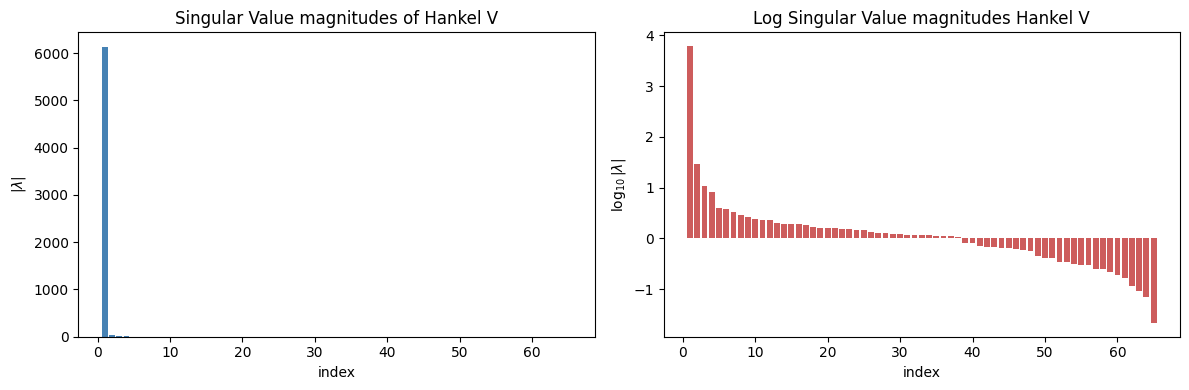

eff_rank: 1, stable_rank: 1.00, shape: (66, 65), non-zero rows :66, non-zero cols:65
top-r leverage spread: min=0.01376 max=0.01696 (uniform would be 0.01515)
row-space coherence score: 1.119
****************************Q-function****************************


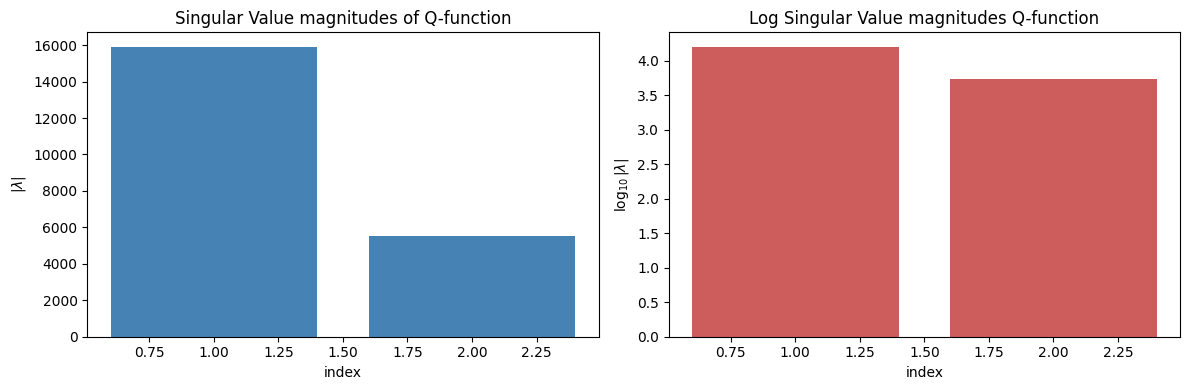

 37%|███▋      | 551/1500 [01:41<18:20,  1.16s/it]

eff_rank: 2, stable_rank: 1.12, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=1.921e-06 max=0.002153 (uniform would be 0.0002441)
row-space coherence score: 8.817


 37%|███▋      | 561/1500 [01:48<08:32,  1.83it/s]

episode 560 avg_rewarg: 161.0


 38%|███▊      | 571/1500 [01:51<05:45,  2.69it/s]

...

episode 580 avg_rewarg: 92.7


 39%|███▉      | 590/1500 [01:56<02:58,  5.08it/s]

episode 590 avg_rewarg: 62.3


 40%|███▉      | 599/1500 [01:59<03:11,  4.71it/s]

episode 600 avg_rewarg: 64.8
****************************Hankel Q****************************


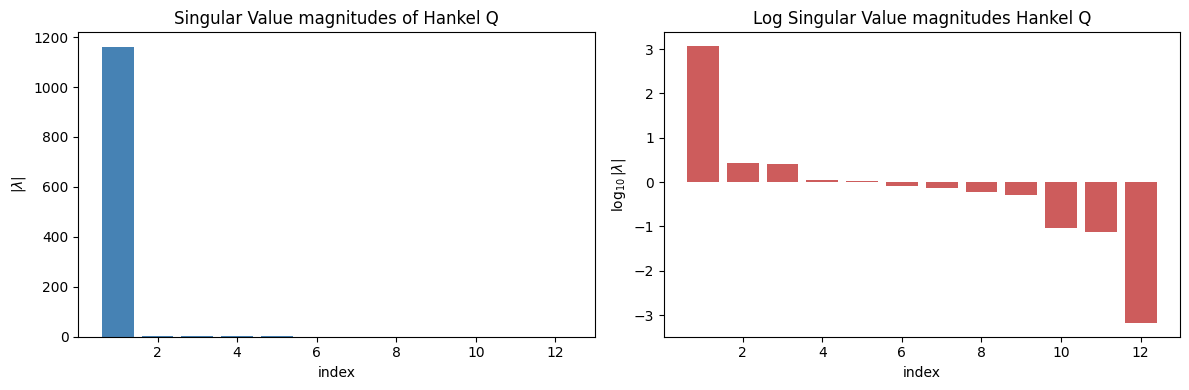

eff_rank: 1, stable_rank: 1.00, shape: (12, 12), non-zero rows :12, non-zero cols:12
top-r leverage spread: min=0.07912 max=0.08779 (uniform would be 0.08333)
row-space coherence score: 1.054
****************************Hankel V****************************


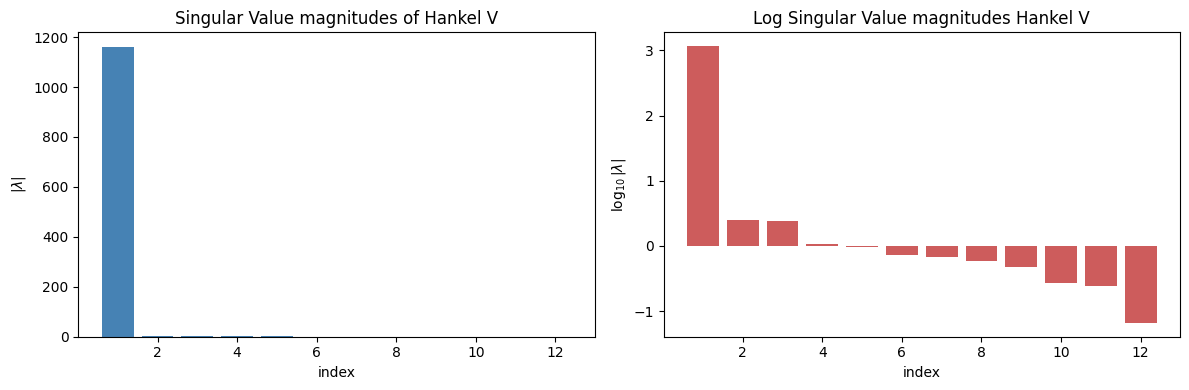

eff_rank: 1, stable_rank: 1.00, shape: (12, 12), non-zero rows :12, non-zero cols:12
top-r leverage spread: min=0.07909 max=0.08779 (uniform would be 0.08333)
row-space coherence score: 1.054
****************************Q-function****************************


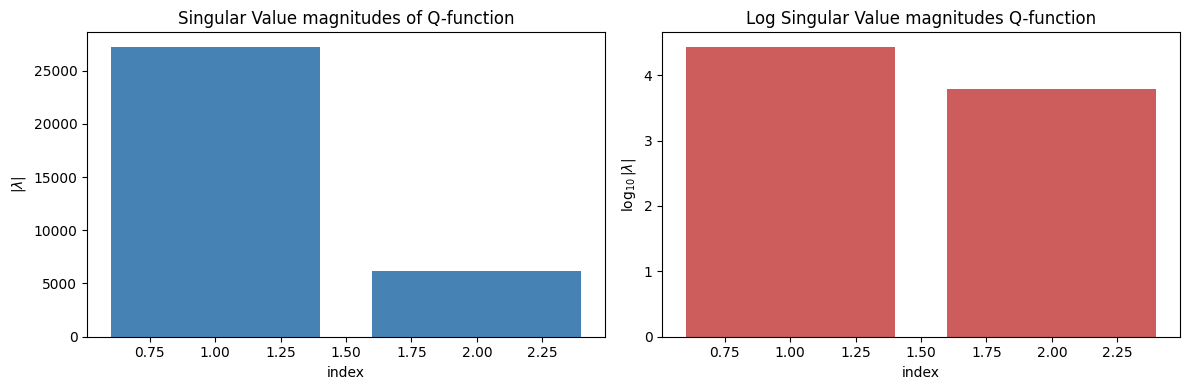

 40%|████      | 601/1500 [01:59<03:32,  4.23it/s]

eff_rank: 1, stable_rank: 1.05, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=1.473e-11 max=0.004673 (uniform would be 0.0002441)
row-space coherence score: 19.14


 41%|████      | 613/1500 [02:00<01:21, 10.83it/s]

episode 610 avg_rewarg: 20.0


 42%|████▏     | 624/1500 [02:01<01:01, 14.26it/s]

...

episode 630 avg_rewarg: 22.5


 43%|████▎     | 642/1500 [02:03<01:24, 10.15it/s]

episode 640 avg_rewarg: 24.3


 43%|████▎     | 650/1500 [02:04<01:20, 10.59it/s]

episode 650 avg_rewarg: 22.5
****************************Hankel Q****************************


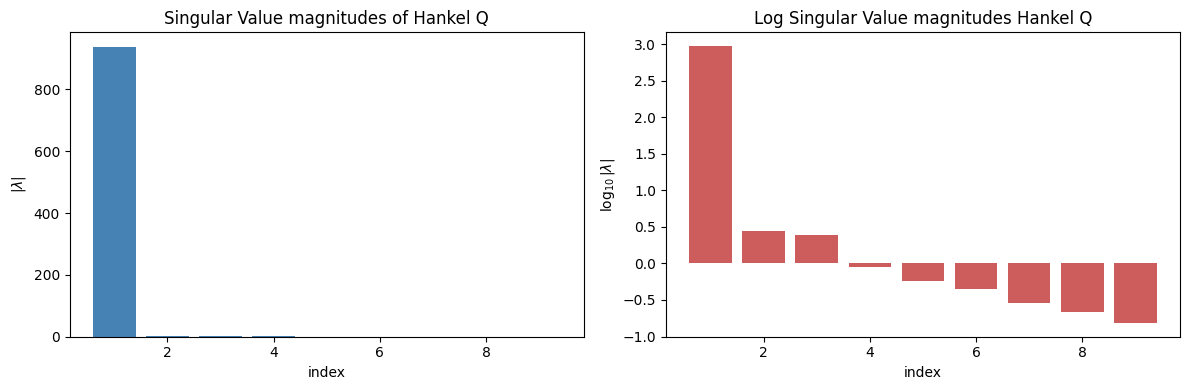

eff_rank: 1, stable_rank: 1.00, shape: (10, 9), non-zero rows :10, non-zero cols:9
top-r leverage spread: min=0.09349 max=0.1067 (uniform would be 0.1)
row-space coherence score: 1.067
****************************Hankel V****************************


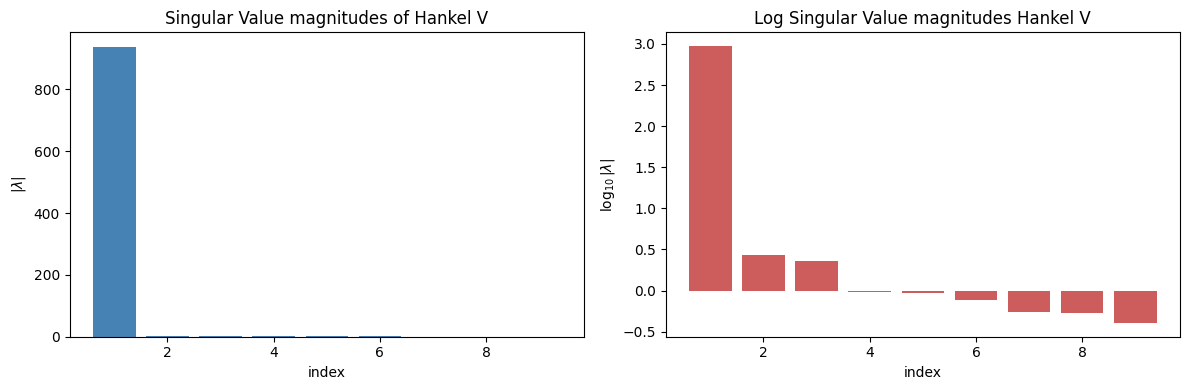

eff_rank: 1, stable_rank: 1.00, shape: (10, 9), non-zero rows :10, non-zero cols:9
top-r leverage spread: min=0.09355 max=0.1066 (uniform would be 0.1)
row-space coherence score: 1.066
****************************Q-function****************************


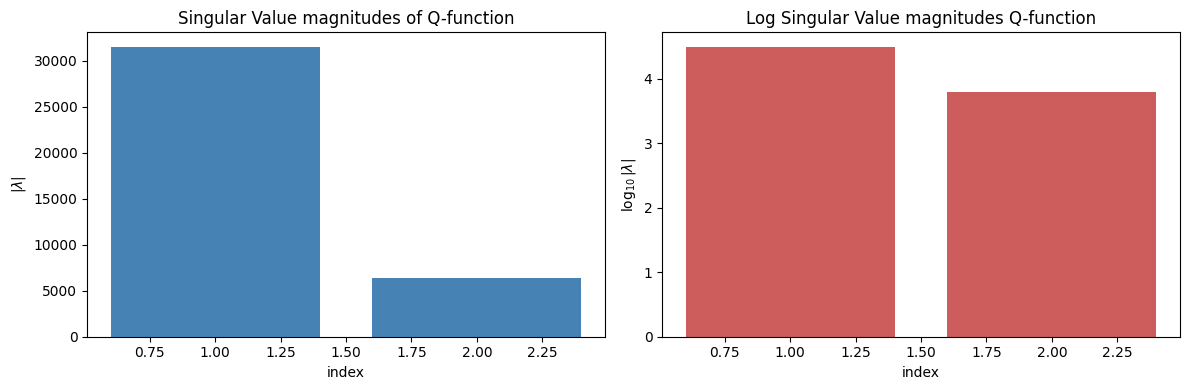

 43%|████▎     | 652/1500 [02:04<01:46,  7.94it/s]

eff_rank: 1, stable_rank: 1.04, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=2.344e-12 max=0.00463 (uniform would be 0.0002441)
row-space coherence score: 18.96


 44%|████▍     | 664/1500 [02:05<01:05, 12.85it/s]

episode 660 avg_rewarg: 19.5


 45%|████▍     | 674/1500 [02:06<00:59, 13.78it/s]

...

episode 680 avg_rewarg: 21.7


 46%|████▋     | 694/1500 [02:07<00:55, 14.65it/s]

episode 690 avg_rewarg: 19.4


 47%|████▋     | 699/1500 [02:08<01:13, 10.86it/s]

episode 700 avg_rewarg: 21.9
****************************Hankel Q****************************


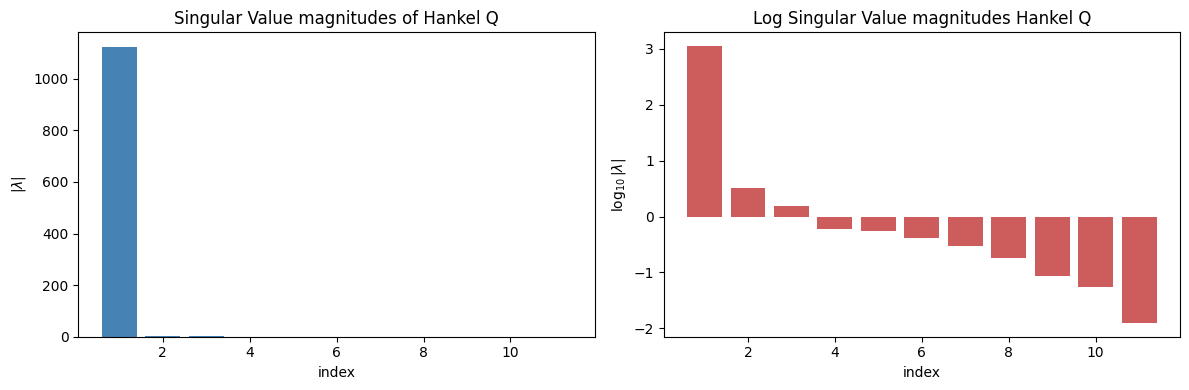

eff_rank: 1, stable_rank: 1.00, shape: (11, 11), non-zero rows :11, non-zero cols:11
top-r leverage spread: min=0.08524 max=0.09645 (uniform would be 0.09091)
row-space coherence score: 1.061
****************************Hankel V****************************


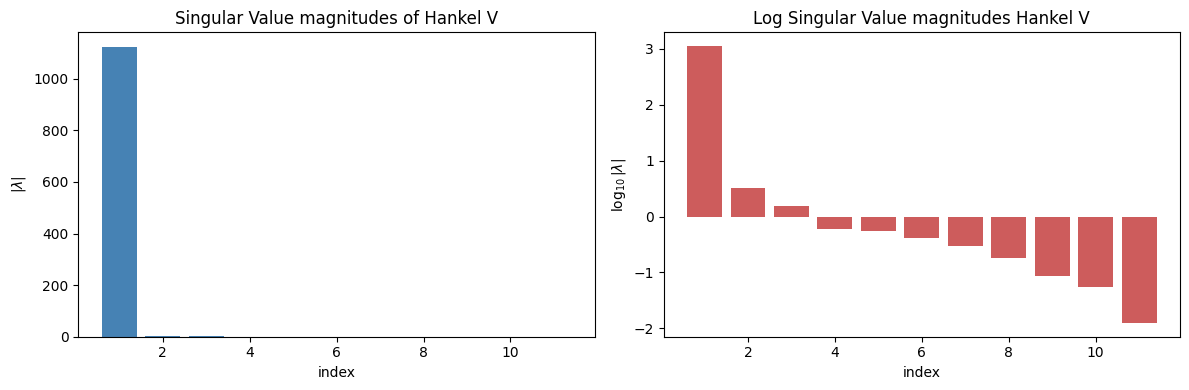

eff_rank: 1, stable_rank: 1.00, shape: (11, 11), non-zero rows :11, non-zero cols:11
top-r leverage spread: min=0.08524 max=0.09645 (uniform would be 0.09091)
row-space coherence score: 1.061
****************************Q-function****************************


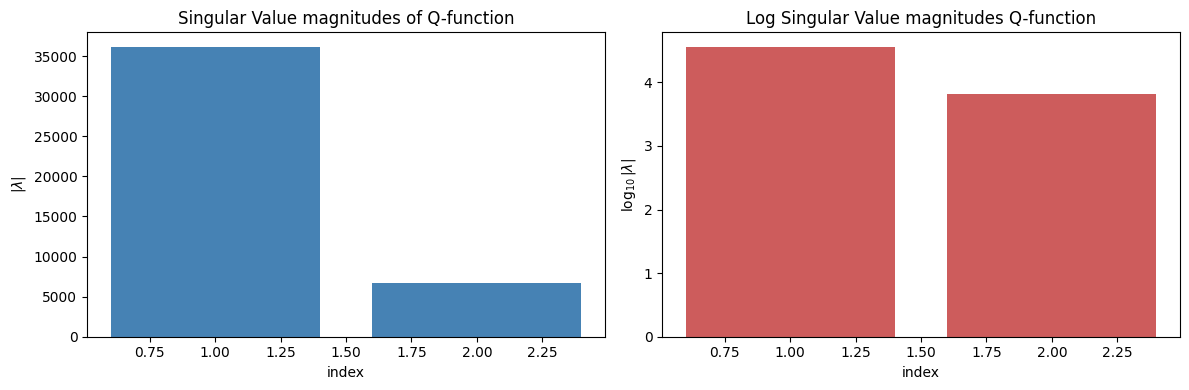

 47%|████▋     | 701/1500 [02:08<01:35,  8.36it/s]

eff_rank: 1, stable_rank: 1.03, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=3.004e-10 max=0.004554 (uniform would be 0.0002441)
row-space coherence score: 18.65


 48%|████▊     | 714/1500 [02:09<00:56, 14.00it/s]

episode 710 avg_rewarg: 16.6


 48%|████▊     | 724/1500 [02:10<00:54, 14.17it/s]

...

episode 730 avg_rewarg: 20.4


 50%|████▉     | 744/1500 [02:11<00:54, 13.77it/s]

episode 740 avg_rewarg: 20.5


 50%|████▉     | 749/1500 [02:12<01:11, 10.50it/s]

episode 750 avg_rewarg: 23.1
****************************Hankel Q****************************


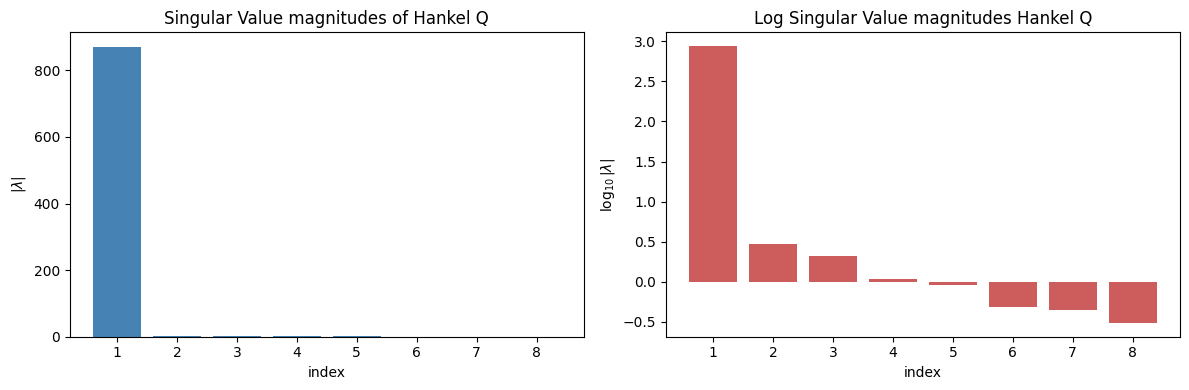

eff_rank: 1, stable_rank: 1.00, shape: (9, 8), non-zero rows :9, non-zero cols:8
top-r leverage spread: min=0.1051 max=0.1167 (uniform would be 0.1111)
row-space coherence score: 1.05
****************************Hankel V****************************


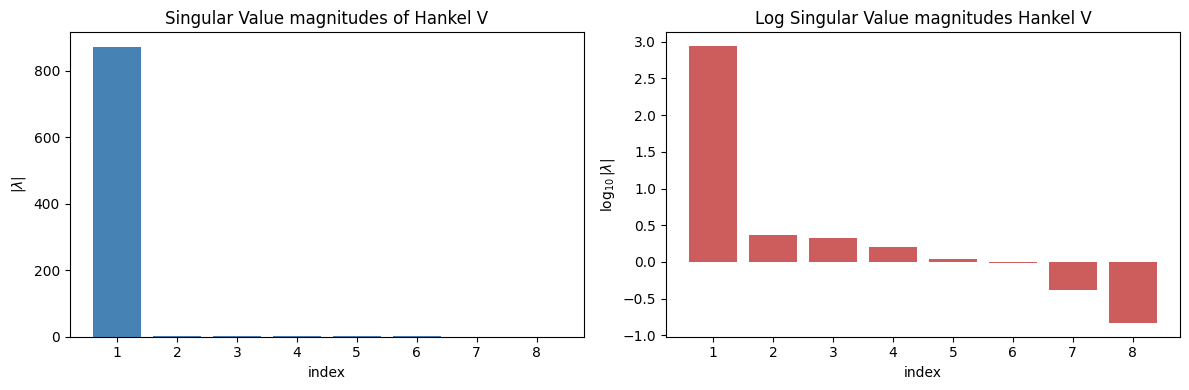

eff_rank: 1, stable_rank: 1.00, shape: (9, 8), non-zero rows :9, non-zero cols:8
top-r leverage spread: min=0.1052 max=0.1167 (uniform would be 0.1111)
row-space coherence score: 1.051
****************************Q-function****************************


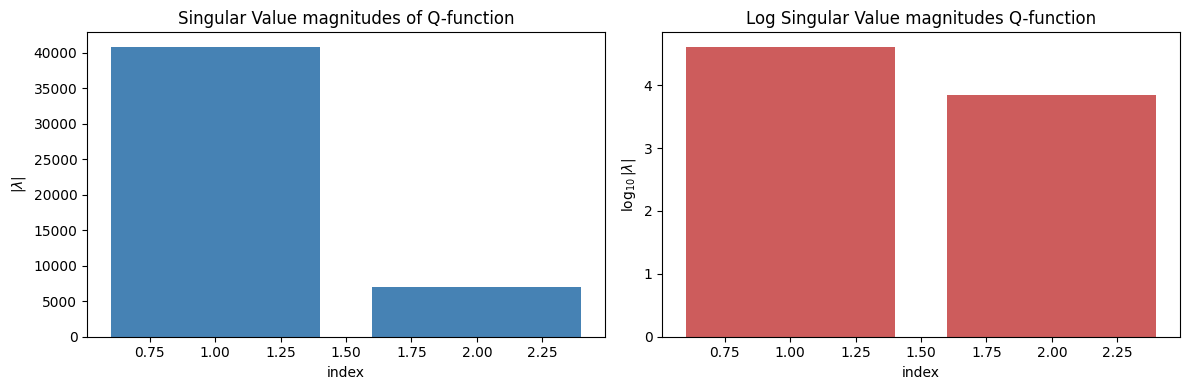

 50%|█████     | 751/1500 [02:13<01:35,  7.83it/s]

eff_rank: 1, stable_rank: 1.03, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=4.773e-11 max=0.004488 (uniform would be 0.0002441)
row-space coherence score: 18.38


 51%|█████     | 762/1500 [02:13<01:00, 12.19it/s]

episode 760 avg_rewarg: 20.3


 51%|█████▏    | 772/1500 [02:14<00:52, 13.95it/s]

...

episode 780 avg_rewarg: 21.7


 53%|█████▎    | 793/1500 [02:16<00:58, 12.00it/s]

episode 790 avg_rewarg: 22.1


 53%|█████▎    | 800/1500 [02:17<01:06, 10.54it/s]

episode 800 avg_rewarg: 24.9
****************************Hankel Q****************************


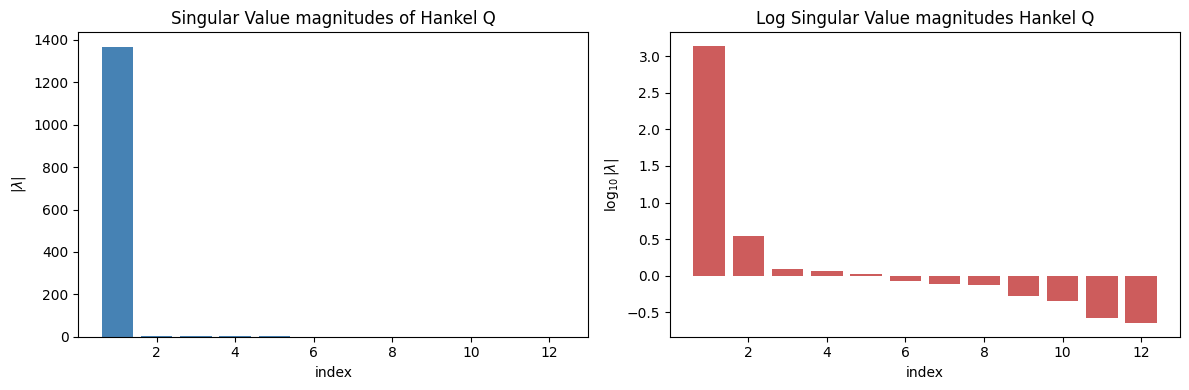

eff_rank: 1, stable_rank: 1.00, shape: (13, 12), non-zero rows :13, non-zero cols:12
top-r leverage spread: min=0.07151 max=0.08312 (uniform would be 0.07692)
row-space coherence score: 1.081
****************************Hankel V****************************


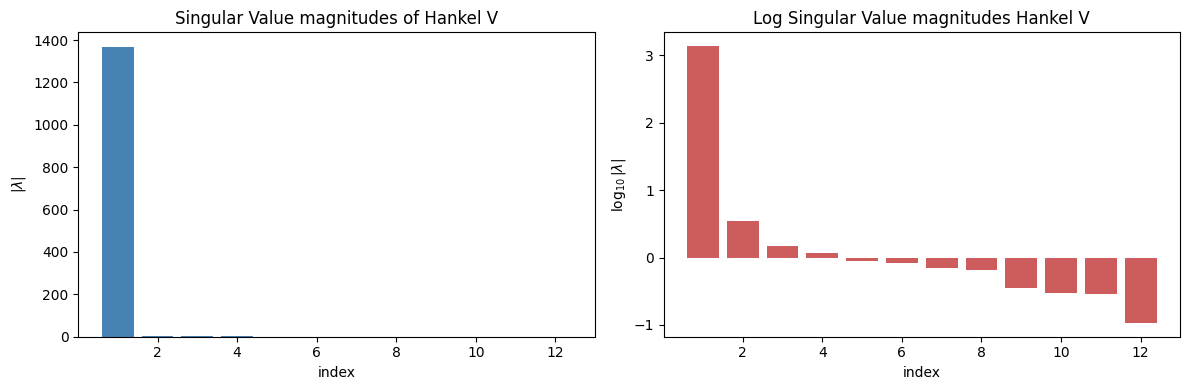

eff_rank: 1, stable_rank: 1.00, shape: (13, 12), non-zero rows :13, non-zero cols:12
top-r leverage spread: min=0.07159 max=0.0831 (uniform would be 0.07692)
row-space coherence score: 1.08
****************************Q-function****************************


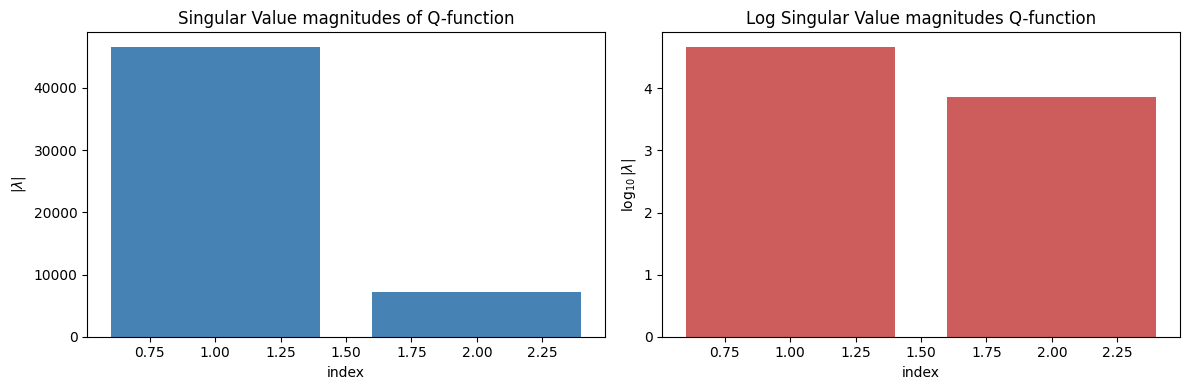

 53%|█████▎    | 802/1500 [02:17<01:28,  7.86it/s]

eff_rank: 1, stable_rank: 1.02, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=4.072e-11 max=0.004403 (uniform would be 0.0002441)
row-space coherence score: 18.04


 54%|█████▍    | 809/1500 [02:18<01:13,  9.35it/s]

episode 810 avg_rewarg: 22.4


 55%|█████▍    | 820/1500 [02:19<00:54, 12.39it/s]

...

episode 830 avg_rewarg: 23.6


 56%|█████▌    | 841/1500 [02:21<00:51, 12.81it/s]

episode 840 avg_rewarg: 23.5


 57%|█████▋    | 850/1500 [02:21<00:54, 11.94it/s]

episode 850 avg_rewarg: 25.9
****************************Hankel Q****************************


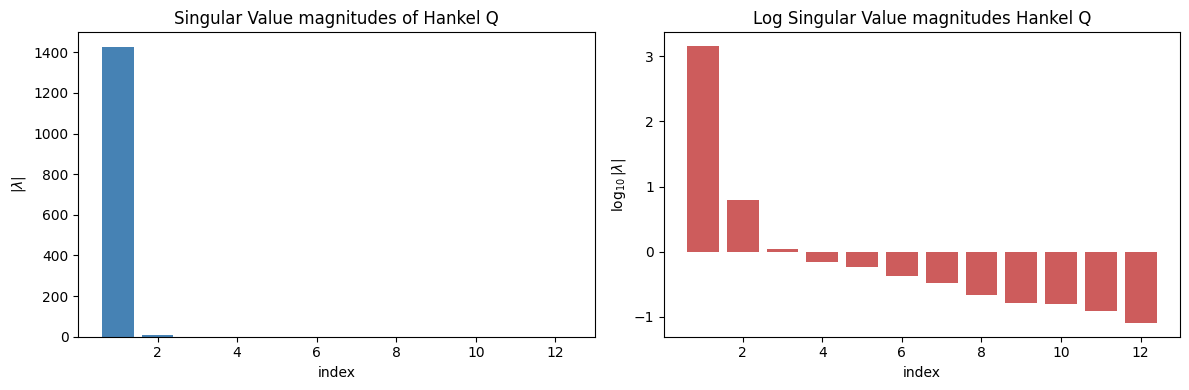

eff_rank: 1, stable_rank: 1.00, shape: (13, 12), non-zero rows :13, non-zero cols:12
top-r leverage spread: min=0.07139 max=0.08377 (uniform would be 0.07692)
row-space coherence score: 1.089
****************************Hankel V****************************


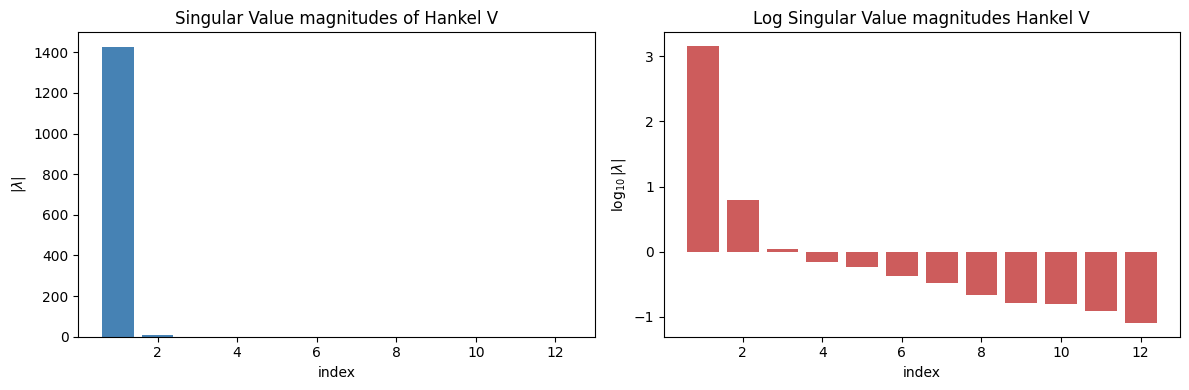

eff_rank: 1, stable_rank: 1.00, shape: (13, 12), non-zero rows :13, non-zero cols:12
top-r leverage spread: min=0.07139 max=0.08377 (uniform would be 0.07692)
row-space coherence score: 1.089
****************************Q-function****************************


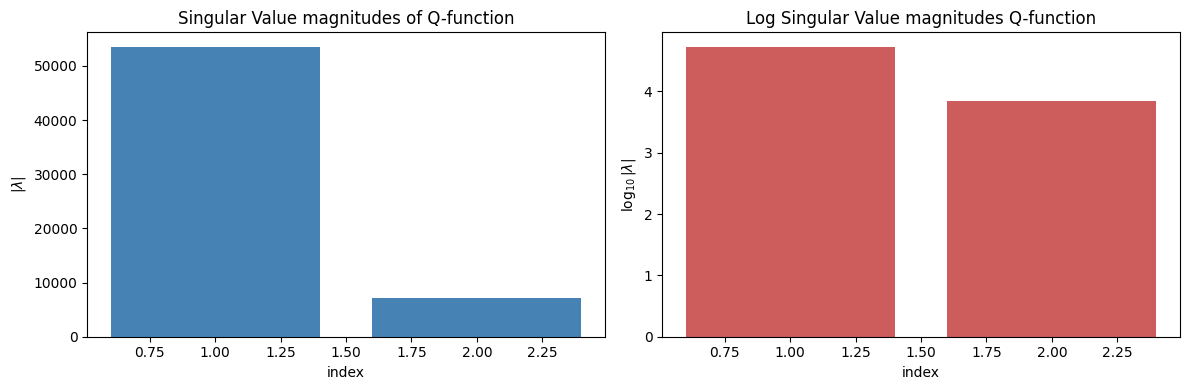

 57%|█████▋    | 852/1500 [02:22<01:49,  5.90it/s]

eff_rank: 1, stable_rank: 1.02, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=9.221e-12 max=0.004319 (uniform would be 0.0002441)
row-space coherence score: 17.69


 58%|█████▊    | 863/1500 [02:23<00:56, 11.22it/s]

episode 860 avg_rewarg: 22.6


 58%|█████▊    | 870/1500 [02:24<01:00, 10.49it/s]

...

episode 880 avg_rewarg: 26.3


 59%|█████▉    | 891/1500 [02:26<00:52, 11.52it/s]

episode 890 avg_rewarg: 24.4


 60%|██████    | 900/1500 [02:27<01:05,  9.12it/s]

episode 900 avg_rewarg: 27.0
****************************Hankel Q****************************


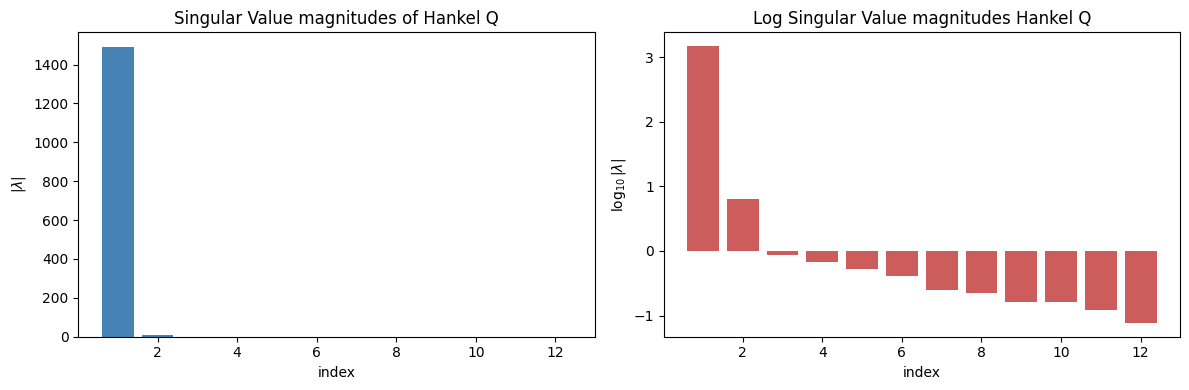

eff_rank: 1, stable_rank: 1.00, shape: (13, 12), non-zero rows :13, non-zero cols:12
top-r leverage spread: min=0.07074 max=0.08457 (uniform would be 0.07692)
row-space coherence score: 1.099
****************************Hankel V****************************


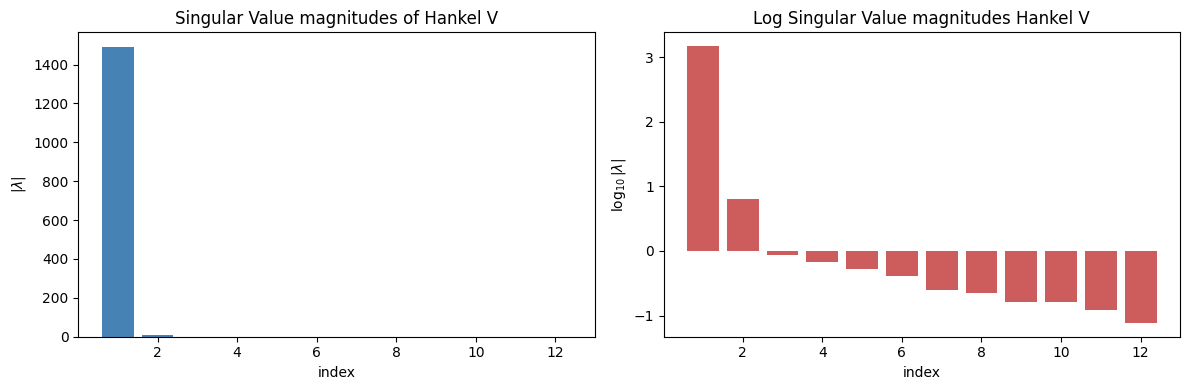

eff_rank: 1, stable_rank: 1.00, shape: (13, 12), non-zero rows :13, non-zero cols:12
top-r leverage spread: min=0.07074 max=0.08457 (uniform would be 0.07692)
row-space coherence score: 1.099
****************************Q-function****************************


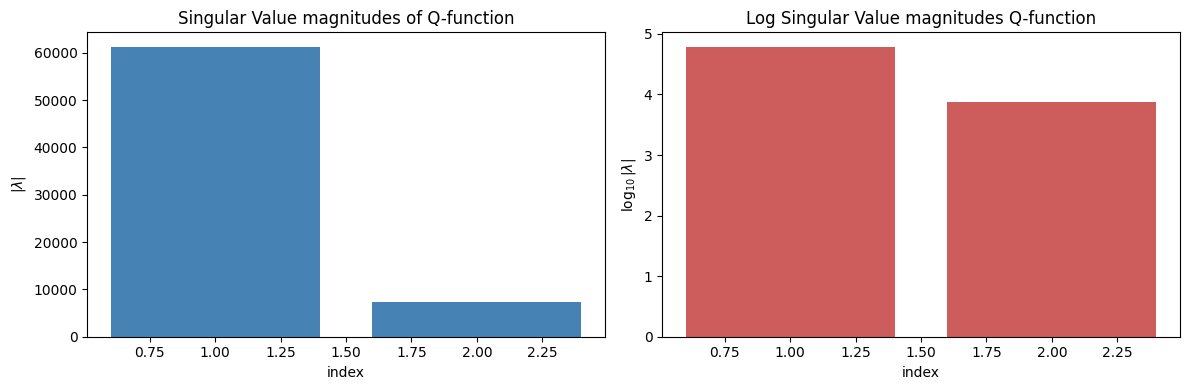

 60%|██████    | 902/1500 [02:28<01:26,  6.94it/s]

eff_rank: 1, stable_rank: 1.01, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=1.741e-11 max=0.004232 (uniform would be 0.0002441)
row-space coherence score: 17.34


 61%|██████    | 912/1500 [02:28<00:51, 11.35it/s]

episode 910 avg_rewarg: 21.3


 62%|██████▏   | 924/1500 [02:29<00:49, 11.68it/s]

...

episode 930 avg_rewarg: 25.9


 63%|██████▎   | 944/1500 [02:31<00:48, 11.50it/s]

episode 940 avg_rewarg: 24.0


 63%|██████▎   | 949/1500 [02:32<00:56,  9.77it/s]

episode 950 avg_rewarg: 23.6
****************************Hankel Q****************************


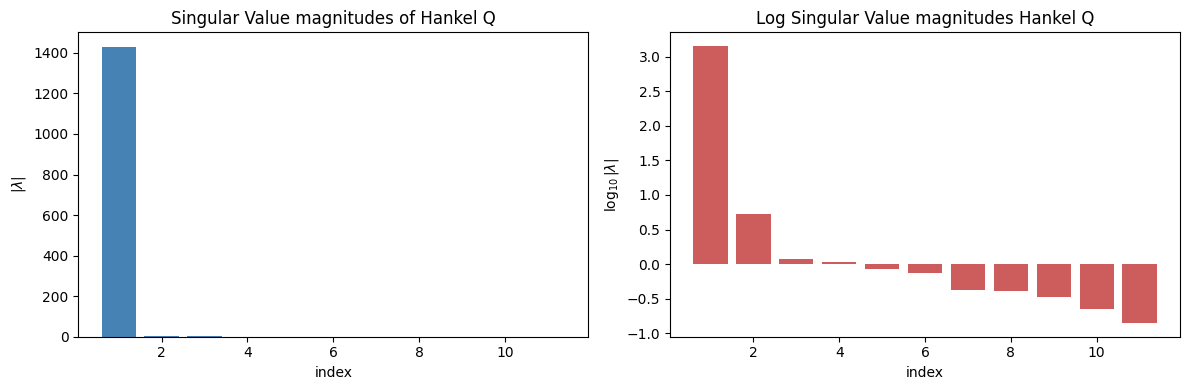

eff_rank: 1, stable_rank: 1.00, shape: (12, 11), non-zero rows :12, non-zero cols:11
top-r leverage spread: min=0.07633 max=0.09172 (uniform would be 0.08333)
row-space coherence score: 1.101
****************************Hankel V****************************


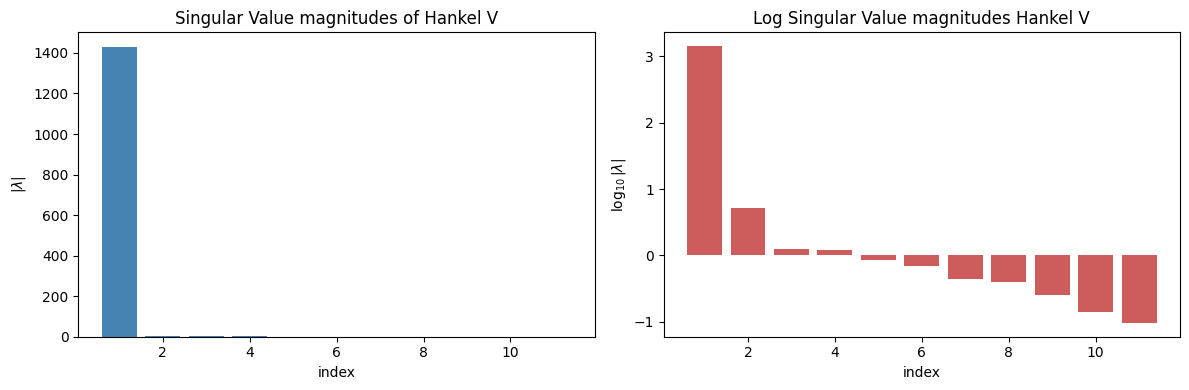

eff_rank: 1, stable_rank: 1.00, shape: (12, 11), non-zero rows :12, non-zero cols:11
top-r leverage spread: min=0.07634 max=0.0917 (uniform would be 0.08333)
row-space coherence score: 1.1
****************************Q-function****************************


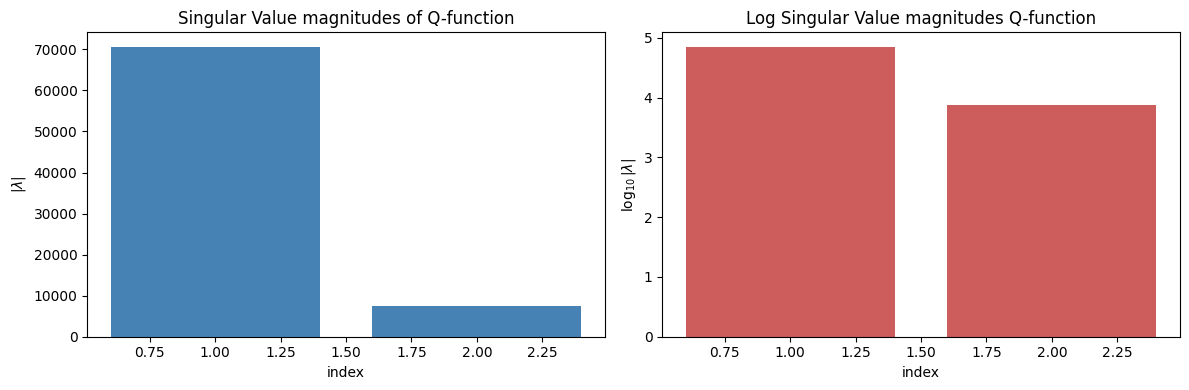

 63%|██████▎   | 951/1500 [02:32<01:12,  7.56it/s]

eff_rank: 1, stable_rank: 1.01, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=9.898e-13 max=0.004128 (uniform would be 0.0002441)
row-space coherence score: 16.91


 64%|██████▍   | 962/1500 [02:33<00:46, 11.46it/s]

episode 960 avg_rewarg: 20.6


 65%|██████▍   | 973/1500 [02:34<00:38, 13.80it/s]

...

episode 980 avg_rewarg: 22.1


 66%|██████▌   | 991/1500 [02:36<00:35, 14.25it/s]

episode 990 avg_rewarg: 21.3


 67%|██████▋   | 1000/1500 [02:37<00:38, 12.94it/s]

episode 1000 avg_rewarg: 20.9
****************************Hankel Q****************************


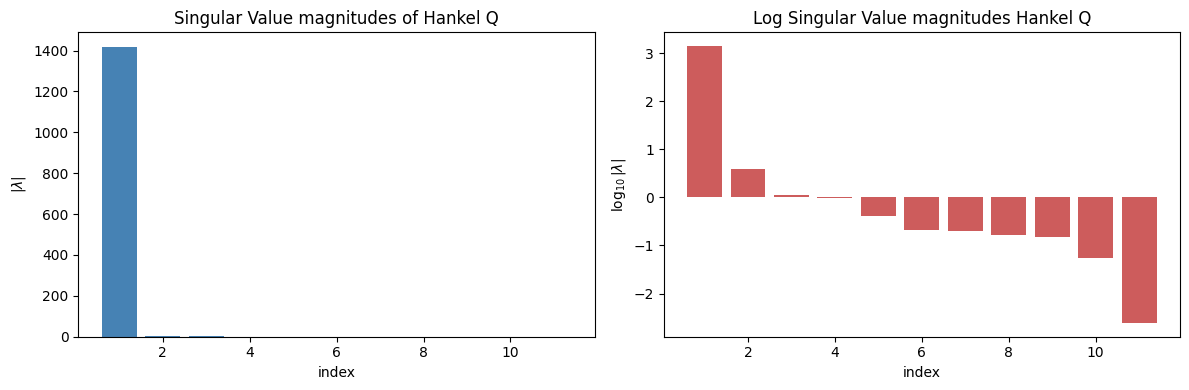

eff_rank: 1, stable_rank: 1.00, shape: (11, 11), non-zero rows :11, non-zero cols:11
top-r leverage spread: min=0.08323 max=0.09983 (uniform would be 0.09091)
row-space coherence score: 1.098
****************************Hankel V****************************


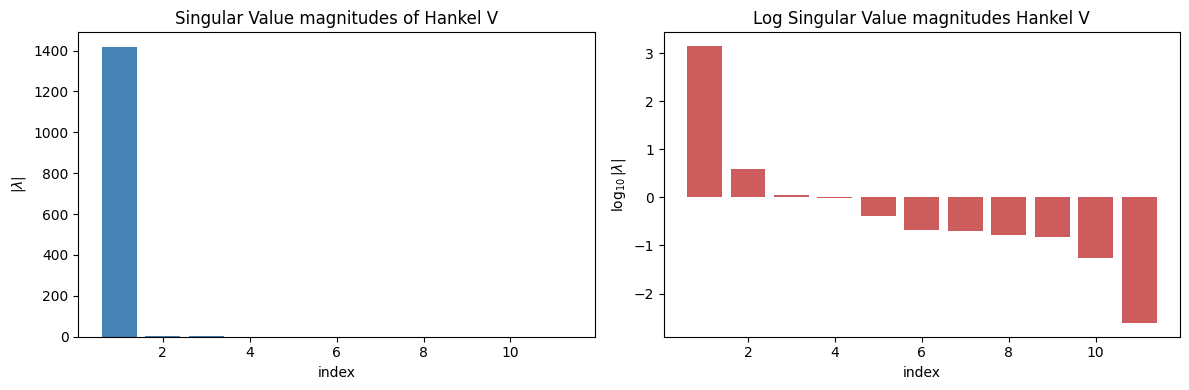

eff_rank: 1, stable_rank: 1.00, shape: (11, 11), non-zero rows :11, non-zero cols:11
top-r leverage spread: min=0.08323 max=0.09983 (uniform would be 0.09091)
row-space coherence score: 1.098
****************************Q-function****************************


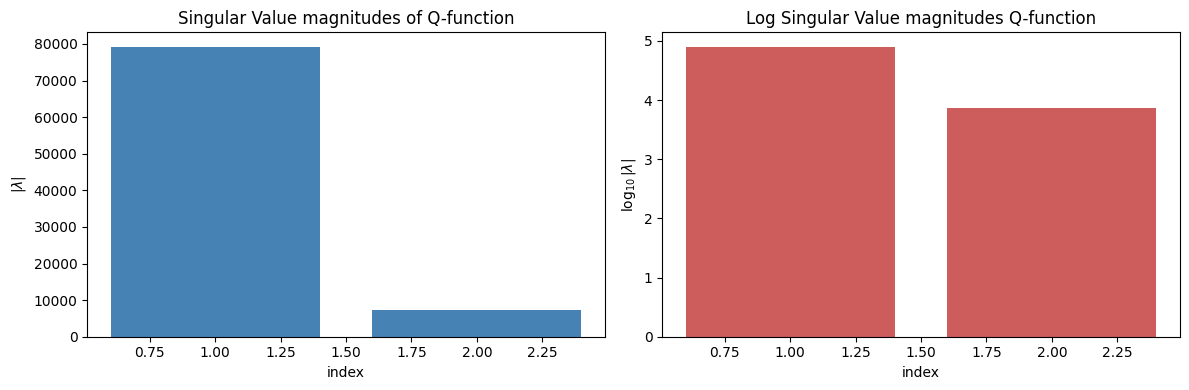

eff_rank: 1, stable_rank: 1.01, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=7.291e-12 max=0.004035 (uniform would be 0.0002441)
row-space coherence score: 16.53


 67%|██████▋   | 1011/1500 [02:38<00:39, 12.32it/s]

episode 1010 avg_rewarg: 19.2


 68%|██████▊   | 1018/1500 [02:38<00:42, 11.26it/s]

episode 1020 avg_rewarg: 19.8


...

episode 1030 avg_rewarg: 19.4


 69%|██████▉   | 1042/1500 [02:40<00:29, 15.56it/s]

episode 1040 avg_rewarg: 19.2


 70%|██████▉   | 1048/1500 [02:41<00:36, 12.40it/s]

episode 1050 avg_rewarg: 18.5
****************************Hankel Q****************************


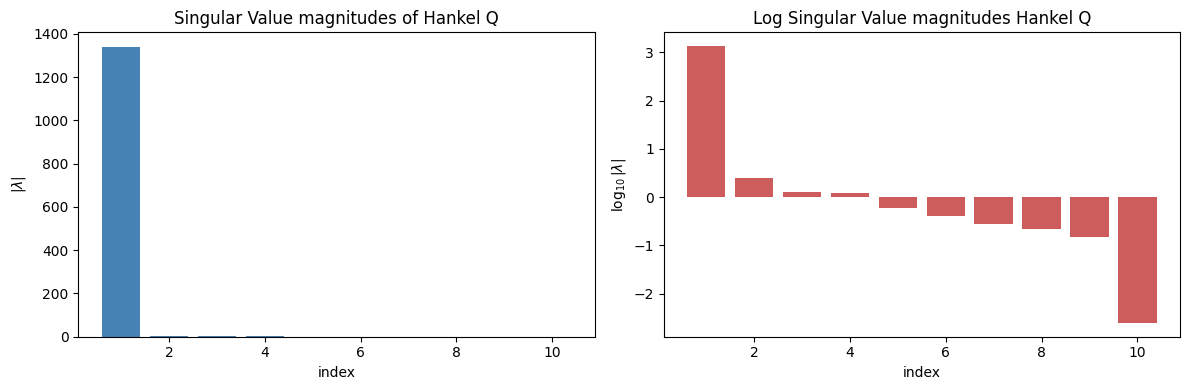

eff_rank: 1, stable_rank: 1.00, shape: (10, 10), non-zero rows :10, non-zero cols:10
top-r leverage spread: min=0.0915 max=0.1095 (uniform would be 0.1)
row-space coherence score: 1.095
****************************Hankel V****************************


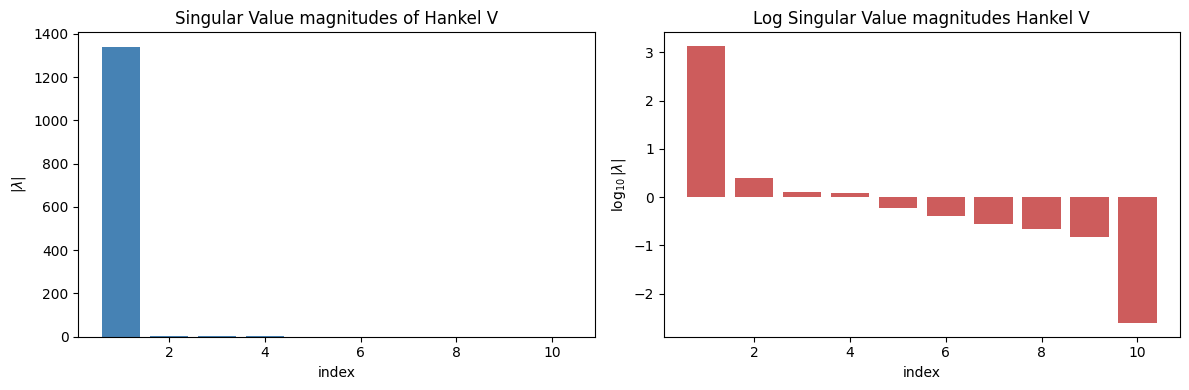

eff_rank: 1, stable_rank: 1.00, shape: (10, 10), non-zero rows :10, non-zero cols:10
top-r leverage spread: min=0.0915 max=0.1095 (uniform would be 0.1)
row-space coherence score: 1.095
****************************Q-function****************************


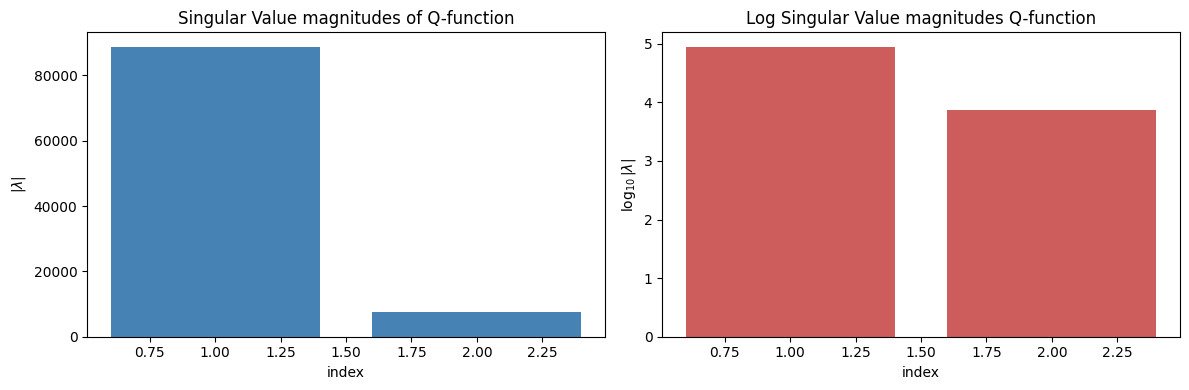

 70%|███████   | 1051/1500 [02:41<00:44, 10.13it/s]

eff_rank: 1, stable_rank: 1.01, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=1.345e-12 max=0.003954 (uniform would be 0.0002441)
row-space coherence score: 16.2


 71%|███████   | 1062/1500 [02:42<00:34, 12.81it/s]

episode 1060 avg_rewarg: 19.6


 72%|███████▏  | 1074/1500 [02:43<00:27, 15.65it/s]

...

episode 1080 avg_rewarg: 18.5


 73%|███████▎  | 1088/1500 [02:44<00:29, 13.81it/s]

episode 1090 avg_rewarg: 18.0


 73%|███████▎  | 1097/1500 [02:44<00:32, 12.58it/s]

episode 1100 avg_rewarg: 19.9
****************************Hankel Q****************************


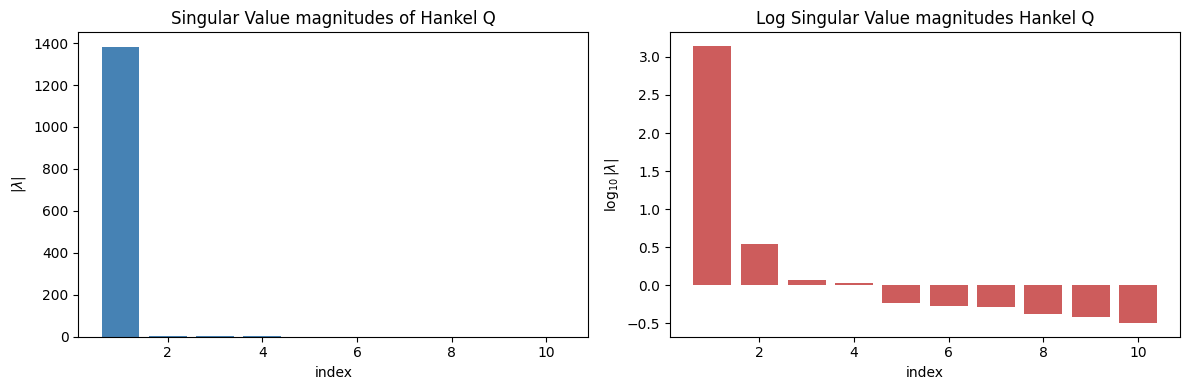

eff_rank: 1, stable_rank: 1.00, shape: (10, 10), non-zero rows :10, non-zero cols:10
top-r leverage spread: min=0.09147 max=0.1097 (uniform would be 0.1)
row-space coherence score: 1.097
****************************Hankel V****************************


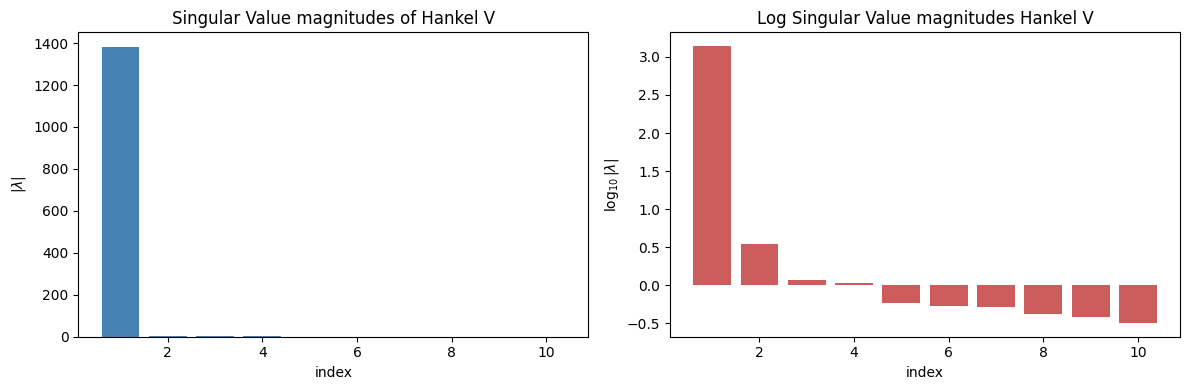

eff_rank: 1, stable_rank: 1.00, shape: (10, 10), non-zero rows :10, non-zero cols:10
top-r leverage spread: min=0.09147 max=0.1097 (uniform would be 0.1)
row-space coherence score: 1.097
****************************Q-function****************************


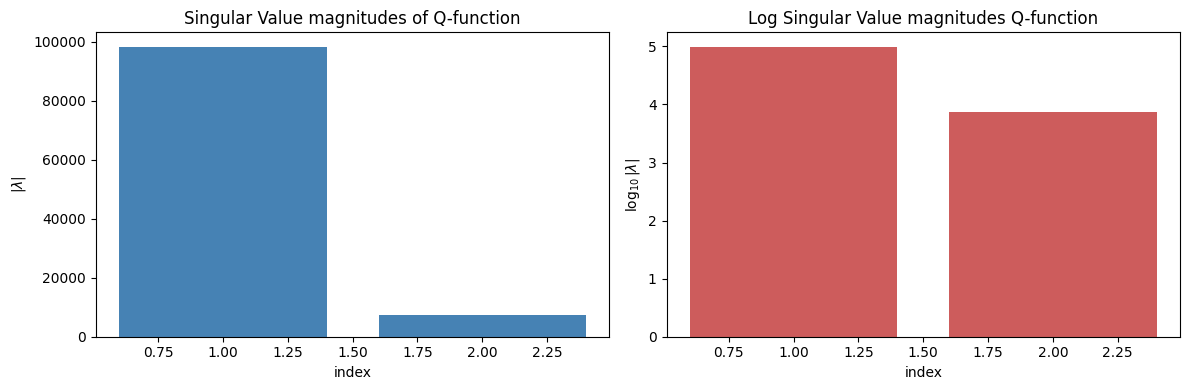

 73%|███████▎  | 1101/1500 [02:45<00:38, 10.47it/s]

eff_rank: 1, stable_rank: 1.01, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=1.54e-12 max=0.003876 (uniform would be 0.0002441)
row-space coherence score: 15.88


 74%|███████▍  | 1113/1500 [02:46<00:26, 14.81it/s]

episode 1110 avg_rewarg: 16.9


 75%|███████▌  | 1126/1500 [02:47<00:20, 18.02it/s]

...

episode 1130 avg_rewarg: 16.7


 76%|███████▌  | 1142/1500 [02:48<00:22, 15.85it/s]

episode 1140 avg_rewarg: 17.8


 77%|███████▋  | 1148/1500 [02:48<00:22, 15.70it/s]

episode 1150 avg_rewarg: 17.7
****************************Hankel Q****************************


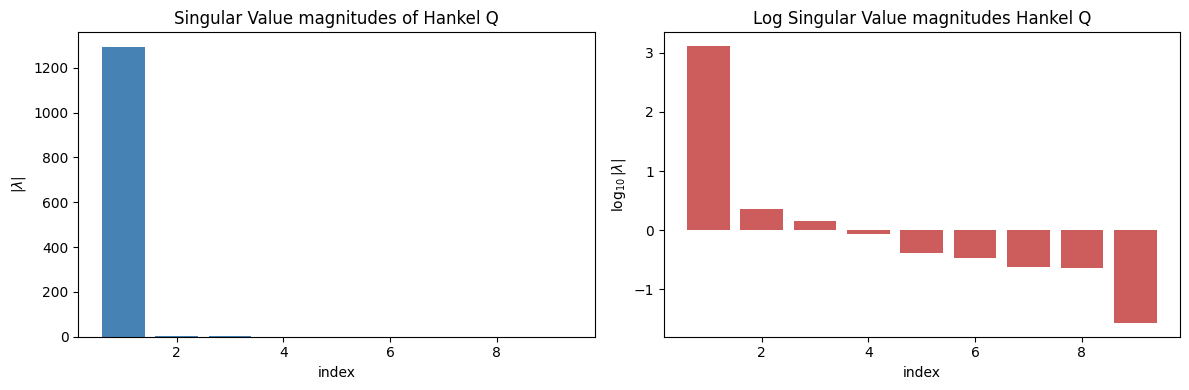

eff_rank: 1, stable_rank: 1.00, shape: (9, 9), non-zero rows :9, non-zero cols:9
top-r leverage spread: min=0.1012 max=0.122 (uniform would be 0.1111)
row-space coherence score: 1.098
****************************Hankel V****************************


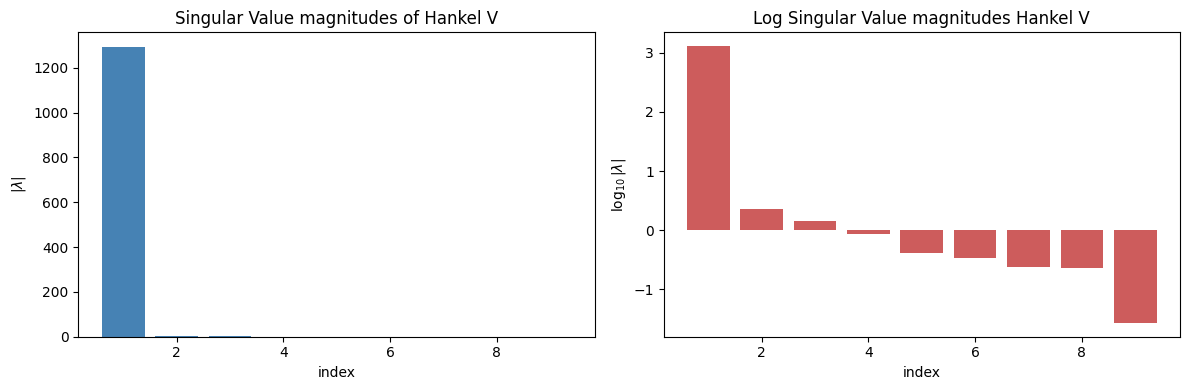

eff_rank: 1, stable_rank: 1.00, shape: (9, 9), non-zero rows :9, non-zero cols:9
top-r leverage spread: min=0.1012 max=0.122 (uniform would be 0.1111)
row-space coherence score: 1.098
****************************Q-function****************************


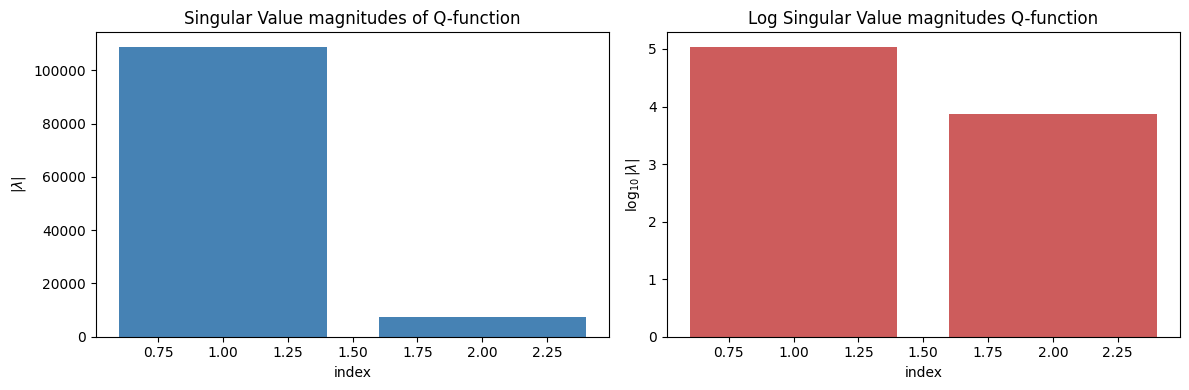

 77%|███████▋  | 1151/1500 [02:49<00:44,  7.81it/s]

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=4.608e-13 max=0.003795 (uniform would be 0.0002441)
row-space coherence score: 15.54


 78%|███████▊  | 1166/1500 [02:50<00:22, 14.94it/s]

episode 1160 avg_rewarg: 16.2


 78%|███████▊  | 1169/1500 [02:50<00:24, 13.30it/s]

...

episode 1180 avg_rewarg: 17.8


 79%|███████▉  | 1192/1500 [02:52<00:21, 14.44it/s]

episode 1190 avg_rewarg: 18.6


 80%|████████  | 1200/1500 [02:52<00:23, 12.84it/s]

episode 1200 avg_rewarg: 18.4
****************************Hankel Q****************************


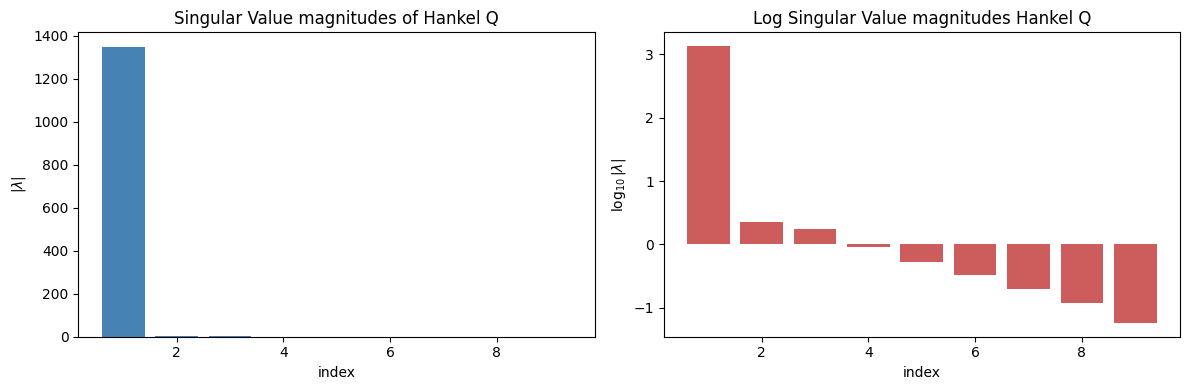

eff_rank: 1, stable_rank: 1.00, shape: (9, 9), non-zero rows :9, non-zero cols:9
top-r leverage spread: min=0.1007 max=0.1224 (uniform would be 0.1111)
row-space coherence score: 1.102
****************************Hankel V****************************


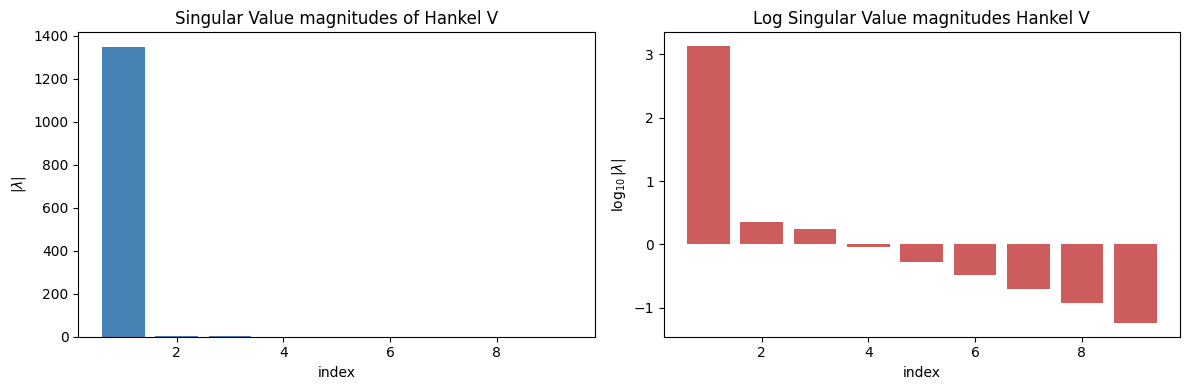

eff_rank: 1, stable_rank: 1.00, shape: (9, 9), non-zero rows :9, non-zero cols:9
top-r leverage spread: min=0.1007 max=0.1224 (uniform would be 0.1111)
row-space coherence score: 1.102
****************************Q-function****************************


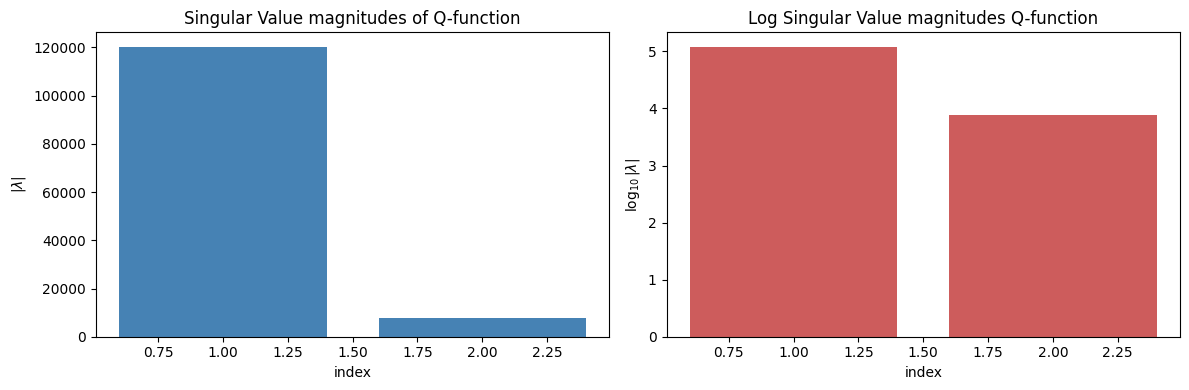

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=1.515e-11 max=0.003717 (uniform would be 0.0002441)
row-space coherence score: 15.23


 81%|████████  | 1211/1500 [02:53<00:20, 14.28it/s]

episode 1210 avg_rewarg: 15.7


 82%|████████▏ | 1224/1500 [02:54<00:15, 17.43it/s]

episode 1220 avg_rewarg: 15.7


...

episode 1230 avg_rewarg: 16.6


 83%|████████▎ | 1242/1500 [02:55<00:14, 18.00it/s]

episode 1240 avg_rewarg: 17.1


 83%|████████▎ | 1248/1500 [02:56<00:19, 13.11it/s]

episode 1250 avg_rewarg: 17.4
****************************Hankel Q****************************


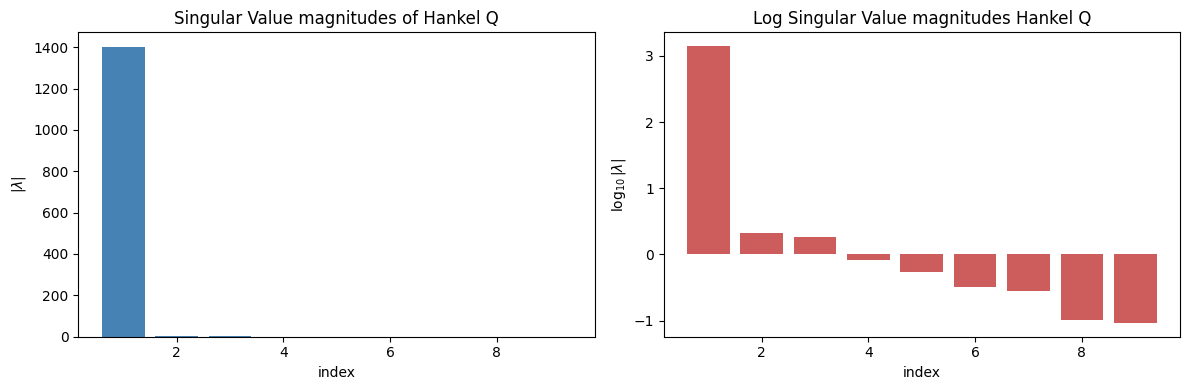

eff_rank: 1, stable_rank: 1.00, shape: (9, 9), non-zero rows :9, non-zero cols:9
top-r leverage spread: min=0.1003 max=0.1229 (uniform would be 0.1111)
row-space coherence score: 1.106
****************************Hankel V****************************


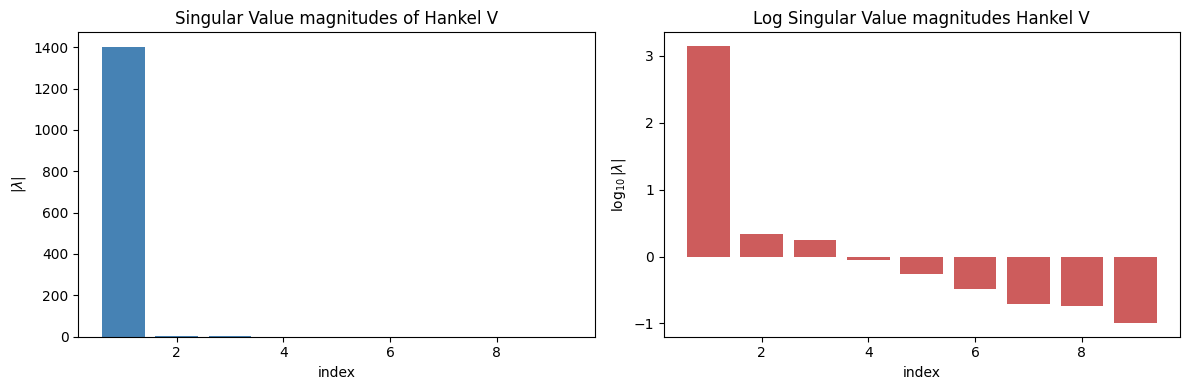

eff_rank: 1, stable_rank: 1.00, shape: (9, 9), non-zero rows :9, non-zero cols:9
top-r leverage spread: min=0.1003 max=0.1229 (uniform would be 0.1111)
row-space coherence score: 1.106
****************************Q-function****************************


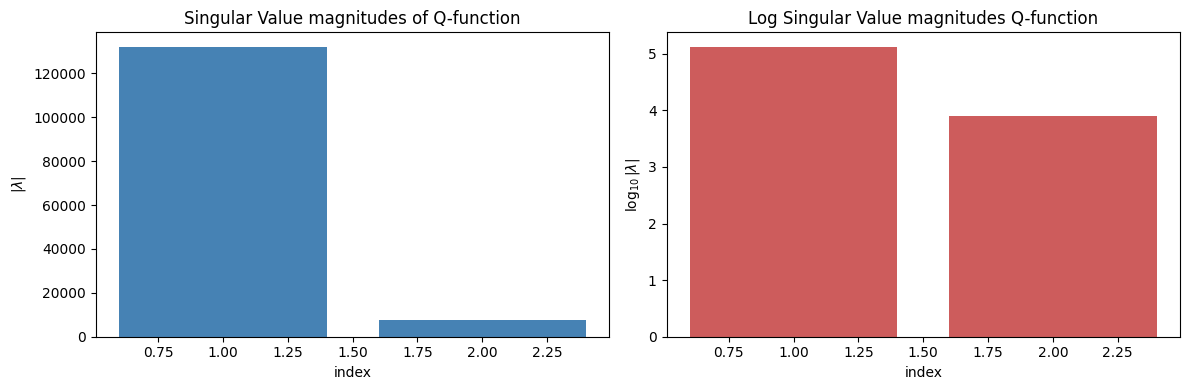

 83%|████████▎ | 1251/1500 [02:56<00:23, 10.50it/s]

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=4.371e-12 max=0.003653 (uniform would be 0.0002441)
row-space coherence score: 14.96


 84%|████████▍ | 1265/1500 [02:57<00:15, 15.44it/s]

episode 1260 avg_rewarg: 16.4


 85%|████████▍ | 1272/1500 [02:58<00:13, 16.97it/s]

...

episode 1280 avg_rewarg: 16.8


 86%|████████▋ | 1294/1500 [02:59<00:12, 16.68it/s]

episode 1290 avg_rewarg: 16.9


 86%|████████▋ | 1297/1500 [02:59<00:14, 13.92it/s]

episode 1300 avg_rewarg: 16.9
****************************Hankel Q****************************


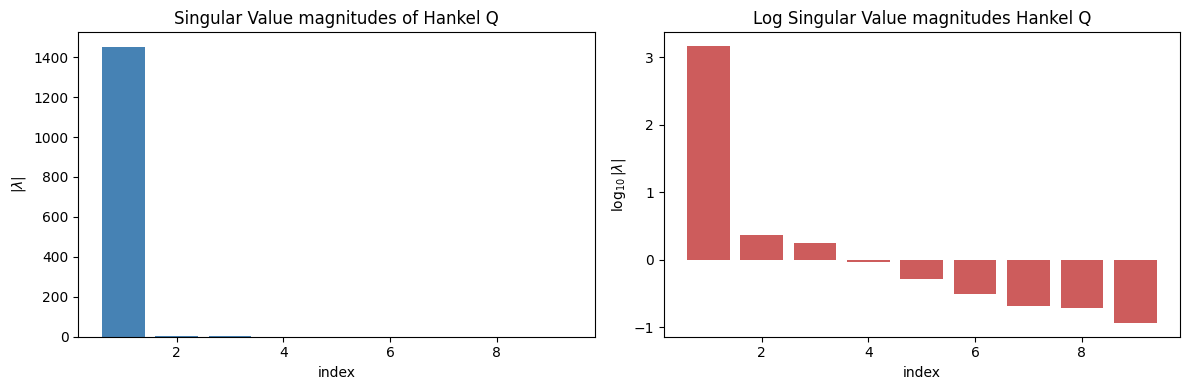

eff_rank: 1, stable_rank: 1.00, shape: (9, 9), non-zero rows :9, non-zero cols:9
top-r leverage spread: min=0.09988 max=0.1234 (uniform would be 0.1111)
row-space coherence score: 1.111
****************************Hankel V****************************


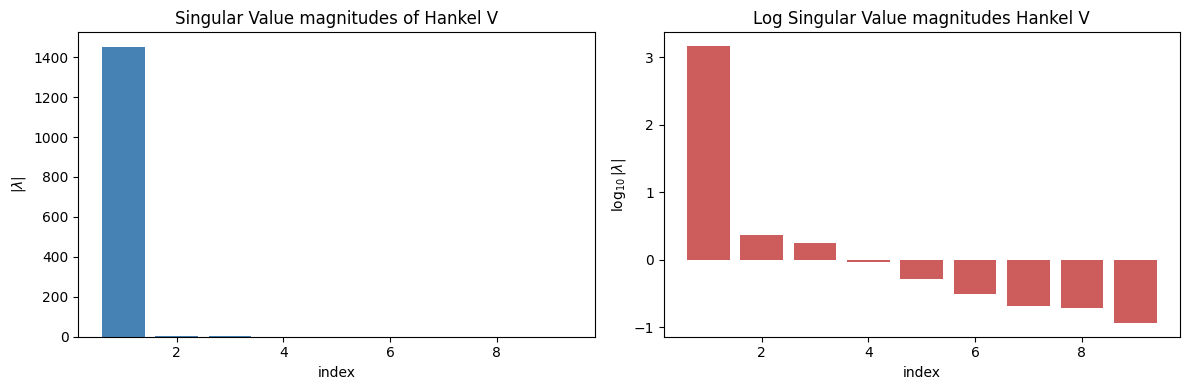

eff_rank: 1, stable_rank: 1.00, shape: (9, 9), non-zero rows :9, non-zero cols:9
top-r leverage spread: min=0.09988 max=0.1234 (uniform would be 0.1111)
row-space coherence score: 1.111
****************************Q-function****************************


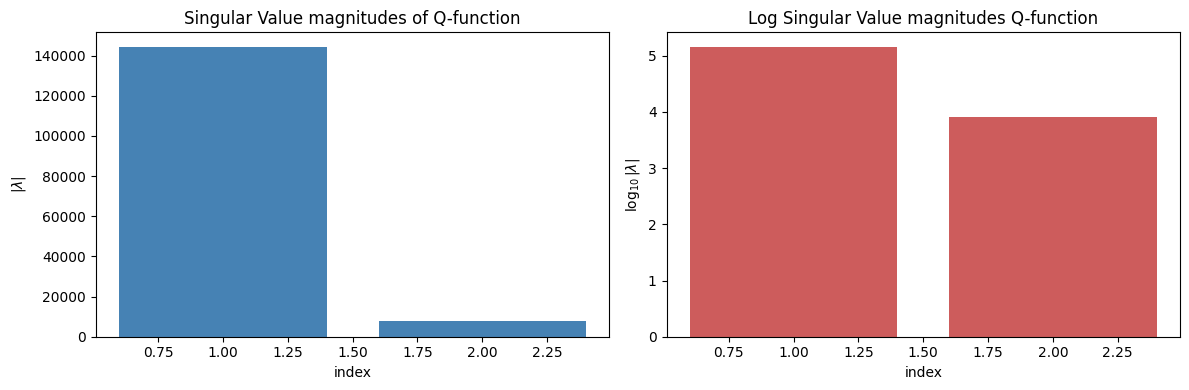

 87%|████████▋ | 1301/1500 [03:00<00:17, 11.40it/s]

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=1.571e-11 max=0.0036 (uniform would be 0.0002441)
row-space coherence score: 14.75


 88%|████████▊ | 1315/1500 [03:01<00:10, 17.81it/s]

episode 1310 avg_rewarg: 15.1


 88%|████████▊ | 1322/1500 [03:01<00:09, 18.90it/s]

...

episode 1330 avg_rewarg: 16.0


 89%|████████▉ | 1342/1500 [03:02<00:07, 20.49it/s]

episode 1340 avg_rewarg: 14.8


 90%|████████▉ | 1348/1500 [03:03<00:10, 13.82it/s]

episode 1350 avg_rewarg: 16.3
****************************Hankel Q****************************


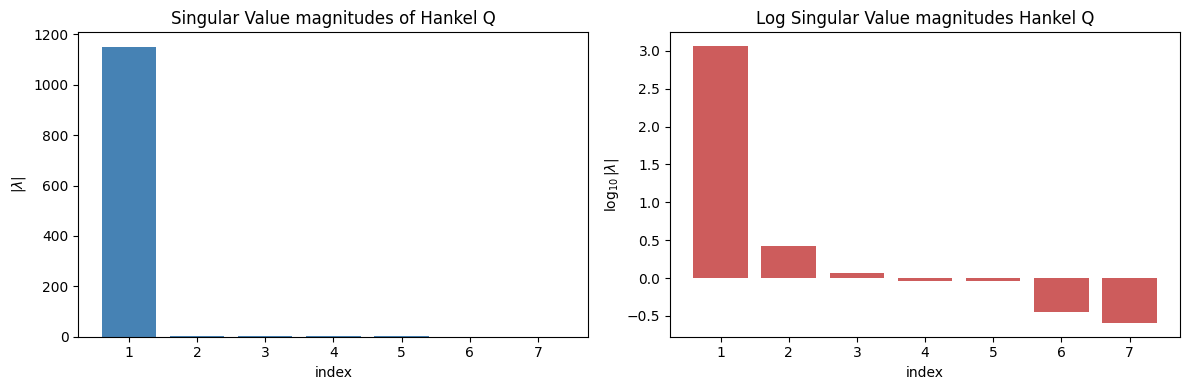

eff_rank: 1, stable_rank: 1.00, shape: (7, 7), non-zero rows :7, non-zero cols:7
top-r leverage spread: min=0.1309 max=0.156 (uniform would be 0.1429)
row-space coherence score: 1.092
****************************Hankel V****************************


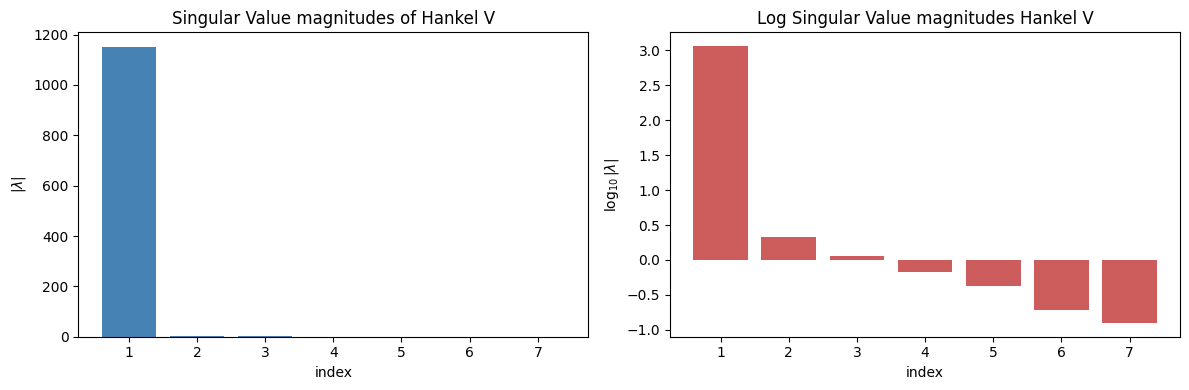

eff_rank: 1, stable_rank: 1.00, shape: (7, 7), non-zero rows :7, non-zero cols:7
top-r leverage spread: min=0.1309 max=0.156 (uniform would be 0.1429)
row-space coherence score: 1.092
****************************Q-function****************************


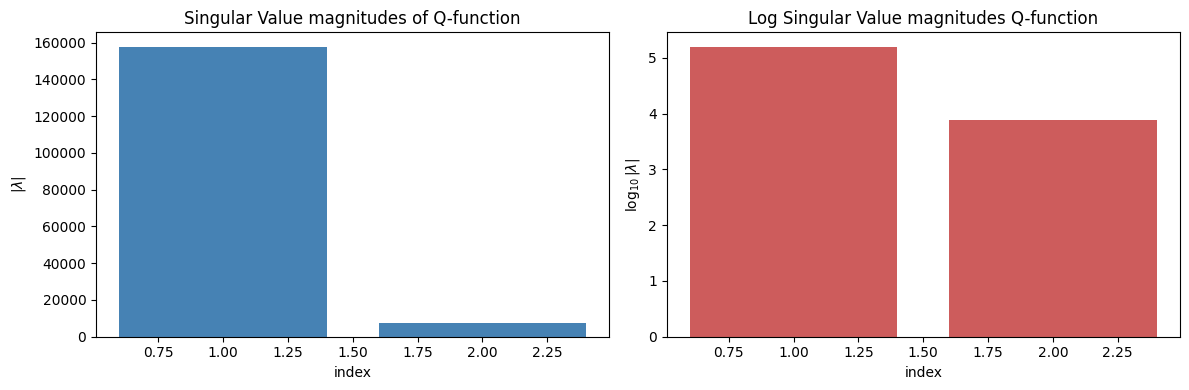

 90%|█████████ | 1351/1500 [03:03<00:14, 10.37it/s]

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=1.111e-12 max=0.003552 (uniform would be 0.0002441)
row-space coherence score: 14.55


 91%|█████████ | 1360/1500 [03:04<00:09, 15.11it/s]

episode 1360 avg_rewarg: 14.4


 92%|█████████▏| 1375/1500 [03:04<00:06, 19.80it/s]

...

episode 1380 avg_rewarg: 17.0


 93%|█████████▎| 1392/1500 [03:06<00:05, 18.17it/s]

episode 1390 avg_rewarg: 15.3


 93%|█████████▎| 1399/1500 [03:06<00:05, 18.33it/s]

episode 1400 avg_rewarg: 16.1
****************************Hankel Q****************************


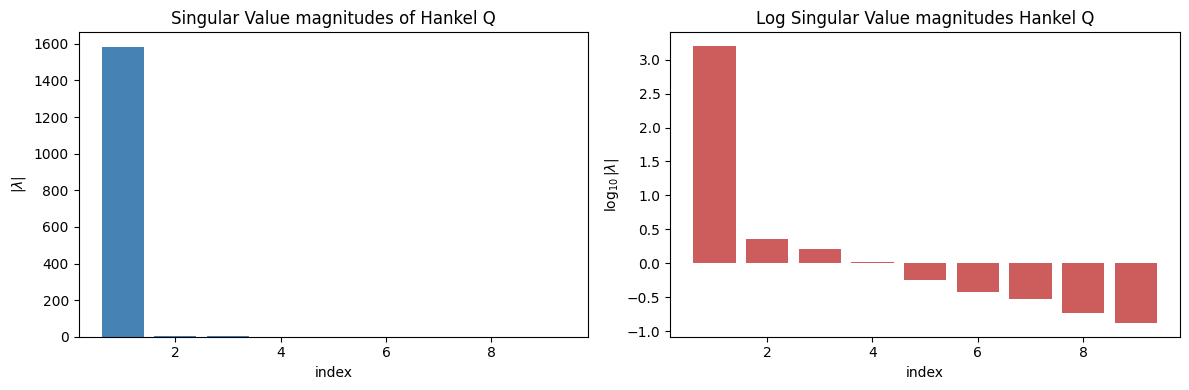

eff_rank: 1, stable_rank: 1.00, shape: (9, 9), non-zero rows :9, non-zero cols:9
top-r leverage spread: min=0.09933 max=0.124 (uniform would be 0.1111)
row-space coherence score: 1.116
****************************Hankel V****************************


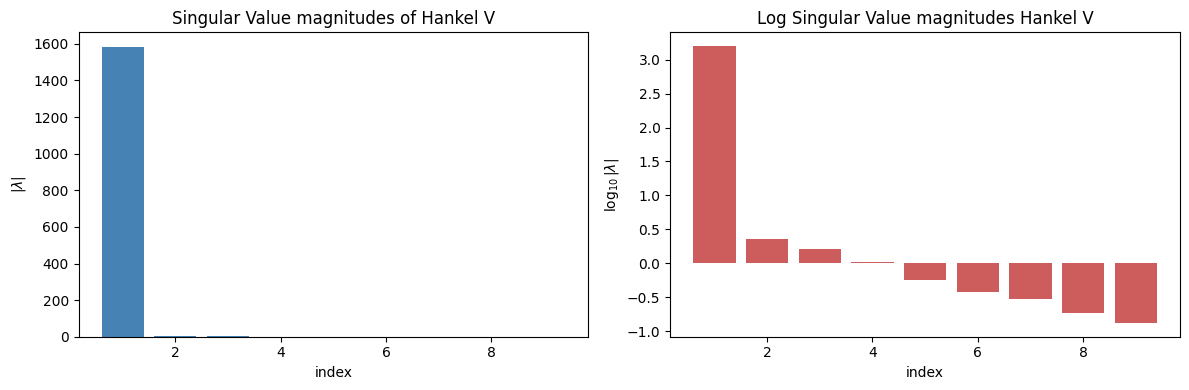

eff_rank: 1, stable_rank: 1.00, shape: (9, 9), non-zero rows :9, non-zero cols:9
top-r leverage spread: min=0.09933 max=0.124 (uniform would be 0.1111)
row-space coherence score: 1.116
****************************Q-function****************************


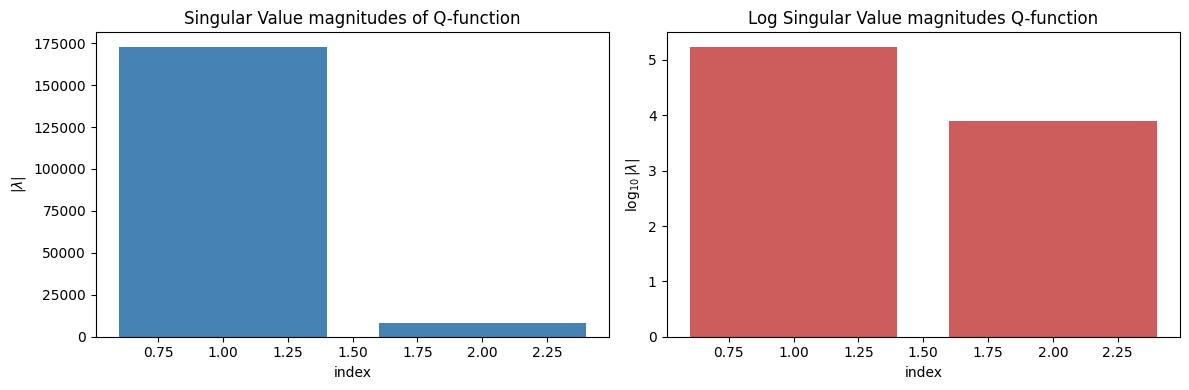

 93%|█████████▎| 1402/1500 [03:07<00:09, 10.40it/s]

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=6.505e-12 max=0.003497 (uniform would be 0.0002441)
row-space coherence score: 14.32


 94%|█████████▍| 1413/1500 [03:07<00:05, 16.62it/s]

episode 1410 avg_rewarg: 14.5


 95%|█████████▌| 1426/1500 [03:08<00:04, 17.15it/s]

...

episode 1430 avg_rewarg: 16.2


 96%|█████████▋| 1444/1500 [03:09<00:03, 17.98it/s]

episode 1440 avg_rewarg: 15.5


 96%|█████████▋| 1447/1500 [03:09<00:03, 15.11it/s]

episode 1450 avg_rewarg: 16.0
****************************Hankel Q****************************


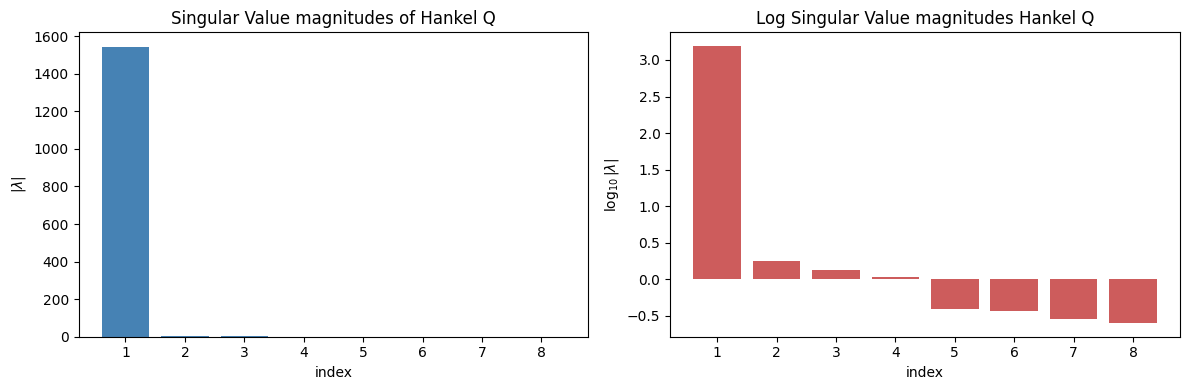

eff_rank: 1, stable_rank: 1.00, shape: (9, 8), non-zero rows :9, non-zero cols:8
top-r leverage spread: min=0.09936 max=0.124 (uniform would be 0.1111)
row-space coherence score: 1.116
****************************Hankel V****************************


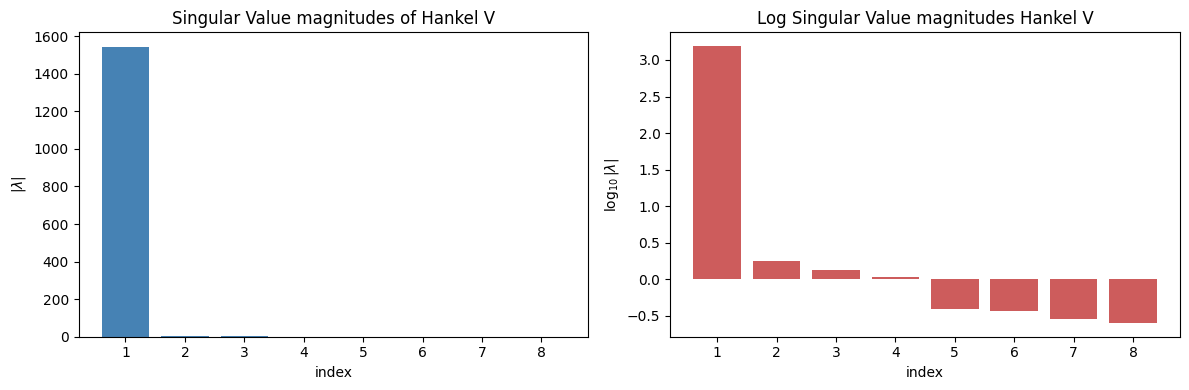

eff_rank: 1, stable_rank: 1.00, shape: (9, 8), non-zero rows :9, non-zero cols:8
top-r leverage spread: min=0.09936 max=0.124 (uniform would be 0.1111)
row-space coherence score: 1.116
****************************Q-function****************************


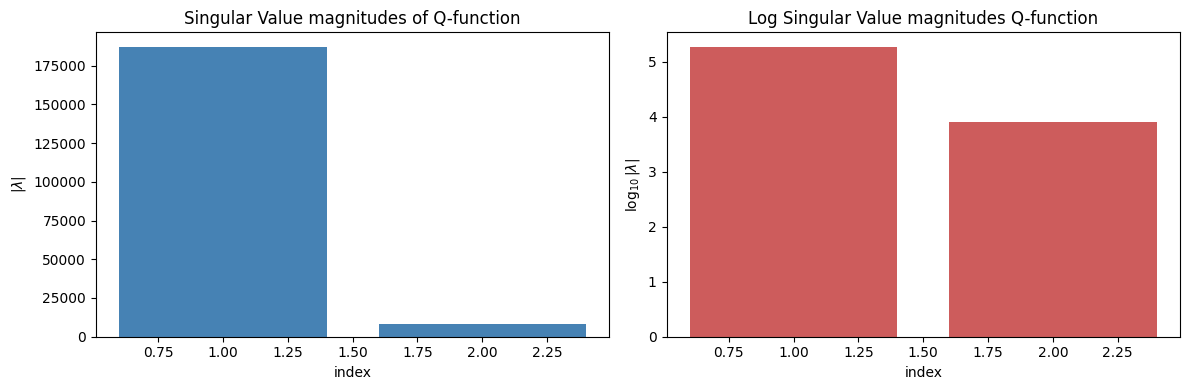

 97%|█████████▋| 1451/1500 [03:10<00:04, 12.00it/s]

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=1.476e-11 max=0.003455 (uniform would be 0.0002441)
row-space coherence score: 14.15


 97%|█████████▋| 1461/1500 [03:11<00:02, 13.86it/s]

episode 1460 avg_rewarg: 14.6


 98%|█████████▊| 1470/1500 [03:11<00:01, 17.93it/s]

...

 99%|█████████▉| 1484/1500 [03:12<00:00, 18.88it/s]

episode 1480 avg_rewarg: 16.7


100%|█████████▉| 1494/1500 [03:13<00:00, 16.83it/s]

episode 1490 avg_rewarg: 15.8


100%|██████████| 1500/1500 [03:13<00:00,  7.76it/s]


In [7]:
t = cfg["training"]
rewards = dqn_training_loop(
    agent, env,
    no_episodes=t["no_episodes"],
    target_network_update_steps=t["target_network_update_steps"],
    train_frequency_steps = t["train_frequency_steps"],
    np_seed=seed,
    analysis_config = analysis,
    DEBUG=False
)

## Training and Analysis Plots (now with pi*(theeta))

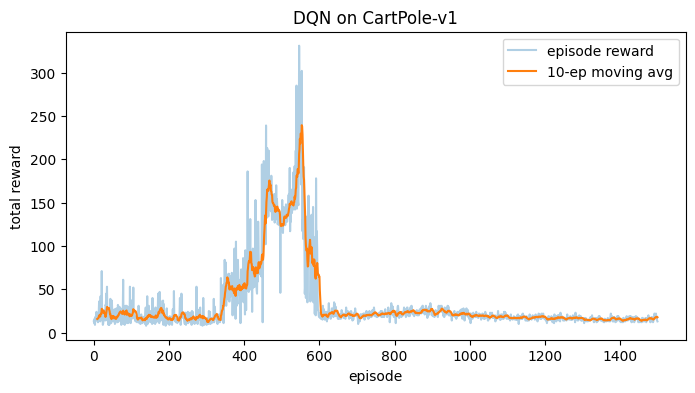

In [8]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on CartPole-v1")
plt.legend(); plt.show()

Hankel Q


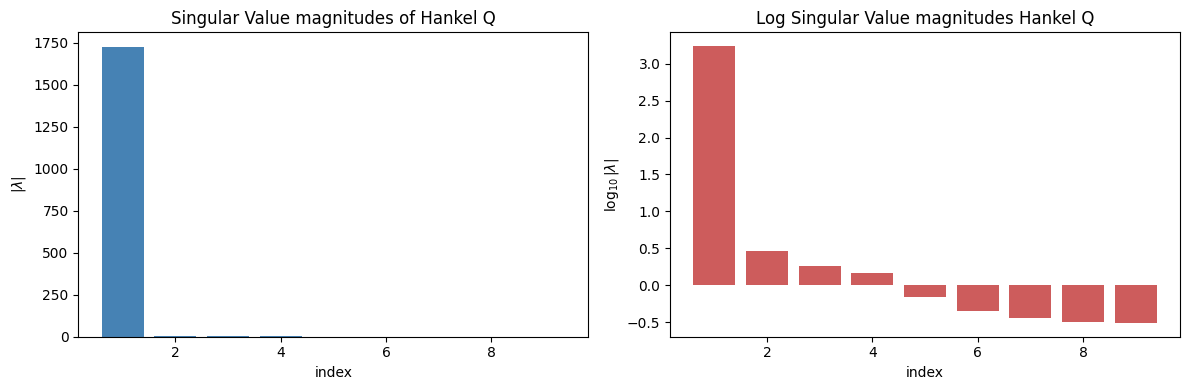

eff_rank: 1, stable_rank: 1.00, shape: (9, 9), non-zero rows :9, non-zero cols:9
top-r leverage spread: min=0.09893 max=0.1245 (uniform would be 0.1111)
row-space coherence score: 1.121
Hankel V


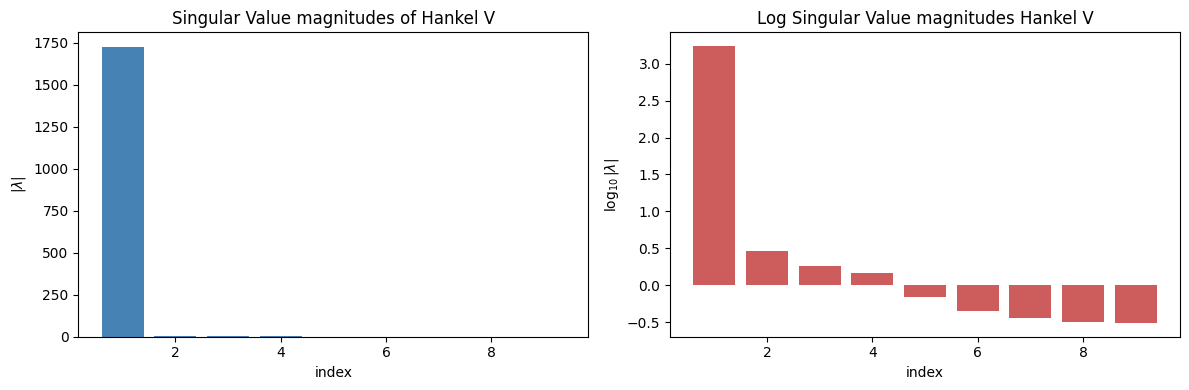

eff_rank: 1, stable_rank: 1.00, shape: (9, 9), non-zero rows :9, non-zero cols:9
top-r leverage spread: min=0.09893 max=0.1245 (uniform would be 0.1111)
row-space coherence score: 1.121
Q-function


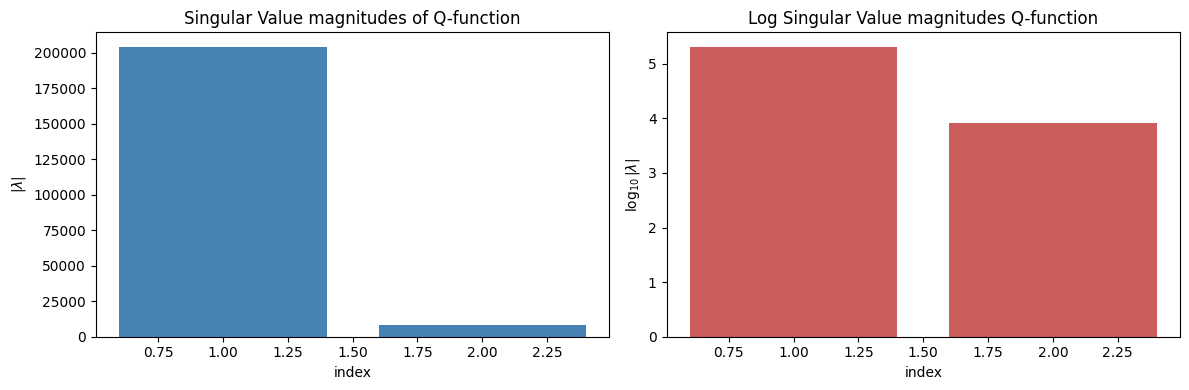

eff_rank: 1, stable_rank: 1.00, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: min=6.05e-12 max=0.003415 (uniform would be 0.0002441)
row-space coherence score: 13.99


In [9]:
for method, names in analysis["methods"]:
    results = method(agent=agent, env=env)
    if not isinstance(results, tuple):
        results = (results,)
    for matrix, name in zip(results, names):
        print(name)
        r, sr, shape, irs, rc, nzc, nzr = row_rank_property_check(matrix, name)
        print(f"eff_rank: {r}, stable_rank: {sr:.2f}, shape: {shape}, non-zero rows :{nzr}, non-zero cols:{nzc}")
        print(f"top-r leverage spread: min={irs.min():.4g} max={irs.max():.4g} (uniform would be {1.0/shape[0]:.4g})")
        print(f"row-space coherence score: {rc:.4g}")